In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zhiqingcui/awidclsr")

print("Path to dataset files:", path)

100%|██████████| 80.8M/80.8M [00:07<00:00, 11.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1


In [ ]:
import kagglehub
import os

# Download the AWID dataset
path = kagglehub.dataset_download("zhiqingcui/awidclsr")

print("Path to dataset files:", path)

# List the files to see what you're working with
print("Files in dataset:", os.listdir(path))

Path to dataset files: /root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1
Files in dataset: ['AWID-CLS-R-Tst', 'AWID-CLS-R-Trn']


In [ ]:
import os

# This lists everything in the folder kagglehub created
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1
/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1


In [ ]:
import zipfile

# Find the zip file in your path
zip_files = [f for f in os.listdir(path) if f.endswith('.zip')]

if zip_files:
    for z in zip_files:
        with zipfile.ZipFile(os.path.join(path, z), 'r') as zip_ref:
            zip_ref.extractall(path)
            print(f"Extracted: {z}")
else:
    print("No zip files found, checking for CSVs...")

No zip files found, checking for CSVs...


Loading a sample of the raw dataset...
Cleaning raw features for correlation calculation...


/tmp/ipykernel_602/1969887296.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features.replace('?', 0, inplace=True)


Generating heatmap for 151 numeric features...


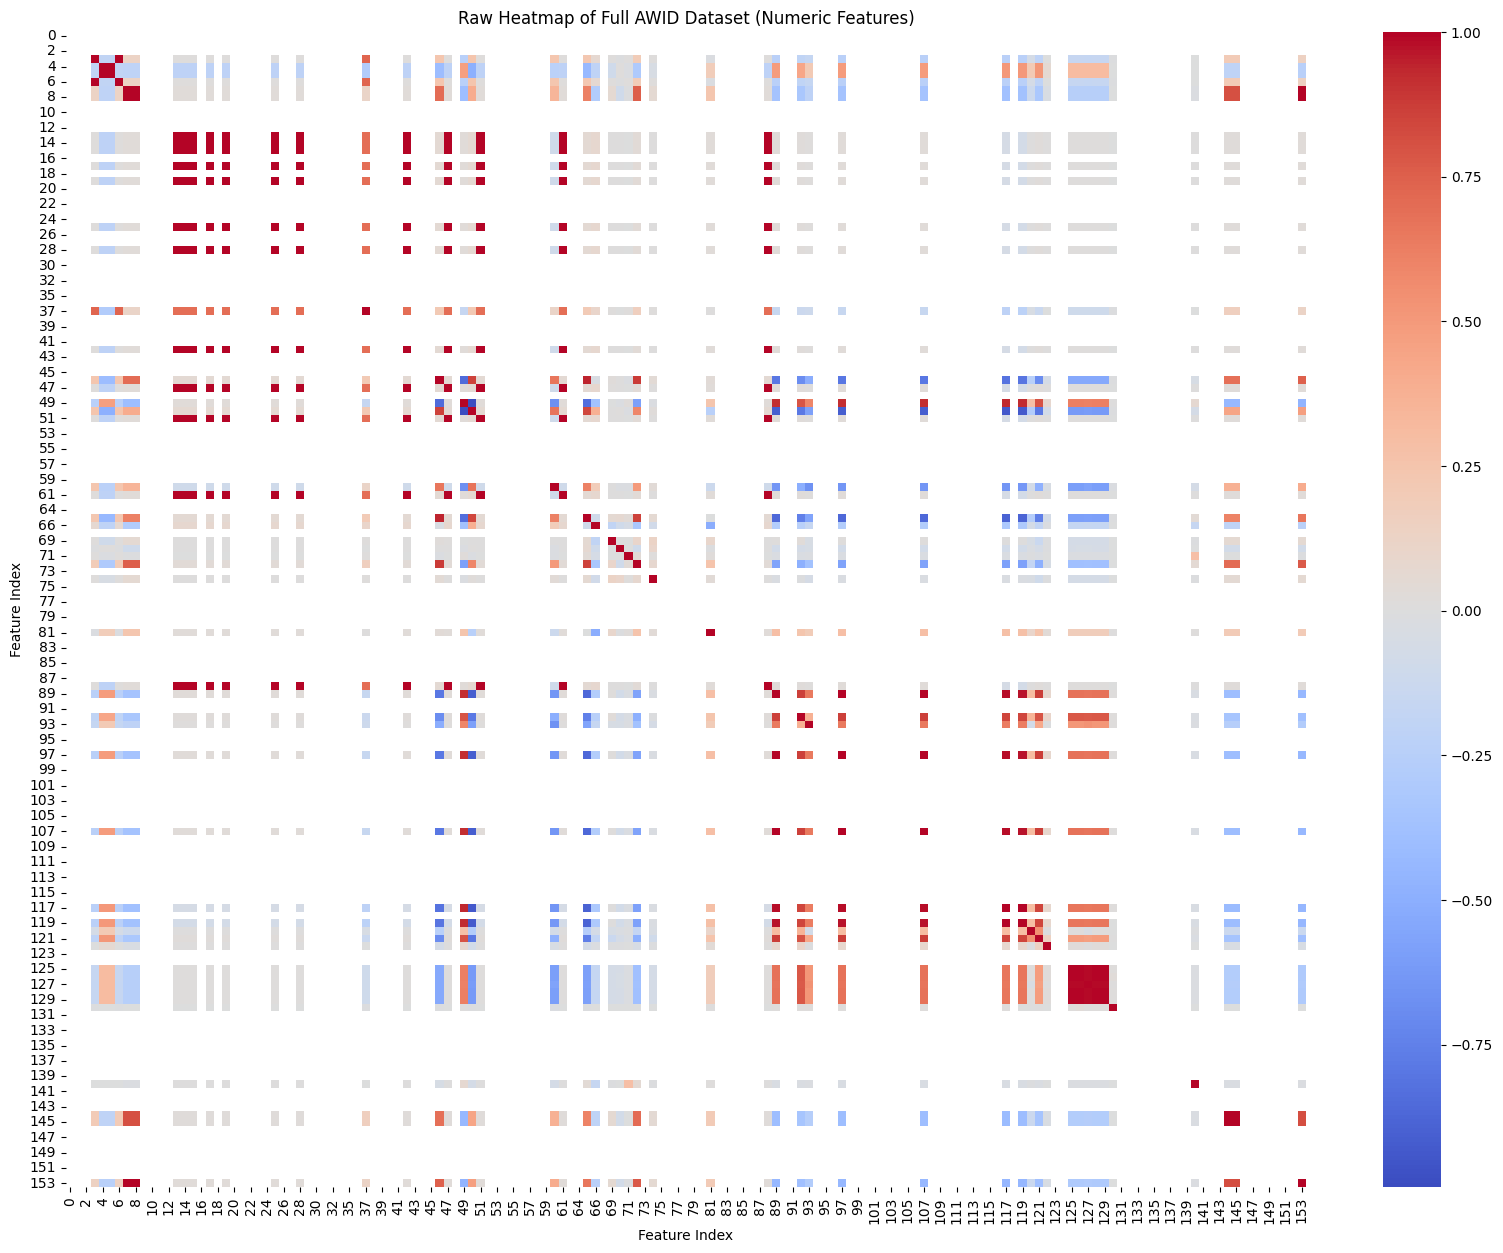

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define train_path before it's used
train_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

# --- STEP 1: LOAD A SAMPLE OF THE FULL DATASET ---
# We load a sample to prevent memory crashes while maintaining statistical relevance [cite: 304]
print("Loading a sample of the raw dataset...")
df_raw_sample = pd.read_csv(train_path, header=None, nrows=50000, low_memory=False)

# --- STEP 2: RAW PREPROCESSING FOR VISUALIZATION ---
def raw_prep_for_heatmap(df):
    # Drop the label column so we only look at feature relationships
    features = df.iloc[:, :-1].copy()

    # Replace symbols with 0 for calculation [cite: 248-250]
    features.replace('?', 0, inplace=True)

    # Convert everything to numeric, forcing errors to NaN
    # We then drop columns that are entirely NaN (non-numeric garbage strings)
    features = features.apply(pd.to_numeric, errors='coerce')
    features.dropna(axis=1, how='all', inplace=True)

    return features

print("Cleaning raw features for correlation calculation...")
features_clean = raw_prep_for_heatmap(df_raw_sample)

# --- STEP 3: GENERATE THE HEATMAP ---
print(f"Generating heatmap for {features_clean.shape[1]} numeric features...")

# Calculate Pearson correlation
corr_matrix = features_clean.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False) # Annot=False because 154 columns is too many for text

plt.title('Raw Heatmap of Full AWID Dataset (Numeric Features)')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

In [ ]:
import pandas as pd

# Unique feature names based on Table 3, duplicates are handled with suffixes
unique_feature_names = [
    "frame.interface_id", "frame.dlt", "frame.offset_shift", "frame.time_epoch", "frame.time_delta",
    "frame.time_delta_displayed", "frame.time_relative", "frame.len", "frame.cap_len", "frame.marked",
    "frame.ignored", "radiotap.version_1", "radiotap.pad_1", "radiotap.length_1", "radiotap.present.tsft_1",
    "radiotap.present.flags_1", "radiotap.present.rate_1", "radiotap.present.channel_1", "radiotap.present.fhss_1",
    "radiotap.present.dbm_antsignal_1", "radiotap.present.dbm_antnoise_1", "radiotap.present.lock_quality_1",
    "radiotap.present.tx_attenuation_1", "radiotap.present.db_tx_attenuation_1", "radiotap.present.dbm_tx_power_1",
    "radiotap.present.antenna_1", "wlan_mgt.fixed.capabilities.ess", "wlan_mgt.fixed.capabilities.ibss",
    "wlan_mgt.fixed.capabilities.cfpoll.ap", "wlan_mgt.fixed.capabilities.privacy",
    "wlan_mgt.fixed.capabilities.preamble", "wlan_mgt.fixed.capabilities.pbce",
    "wlan_mgt.fixed.capabilities.agility", "wlan_mgt.fixed.capabilities.spec_man",
    "wlan_mgt.fixed.capabilities.short_slot_time", "wlan_mgt.fixed.capabilities.apsd",
    "wlan_mgt.fixed.capabilities.radio_measurement", "wlan_mgt.fixed.capabilities.dsss_ofdm",
    "wlan_mgt.fixed.capabilities.del_blk_ack", "wlan_mgt.fixed.capabilities.imm_blk_ack",
    "wlan_mgt.fixed.listen_ival", "wlan_mgt.fixed.current_ap", "wlan_mgt.fixed.status_code",
    "wlan_mgt.fixed.timestamp", "wlan_mgt.fixed.beacon", "wlan_mgt.fixed.aid", "wlan_mgt.fixed.reason_code",
    "wlan_mgt.fixed.auth.alg", "wlan_mgt.fixed.auth_seq", "wlan_mgt.fixed.category_code",
    "wlan_mgt.fixed.htact", "wlan_mgt.fixed.chanwidth", "wlan_mgt.fixed.fragment", "wlan_mgt.fixed.sequence_1",
    "wlan_mgt.tagged.all", "wlan_mgt.ssid", "wlan_mgt.ds.current_channel", "wlan_mgt.tim.dtim_count",
    "wlan_mgt.tim.dtim_period", "wlan_mgt.tim.bmapctl.multicast", "wlan_mgt.tim.bmapctl.offset",
    "wlan_mgt.country_info.environment", "wlan_mgt.rsn.version", "wlan_mgt.rsn.ges.type",
    "wlan_mgt.rsn.pcs.count", "wlan_mgt.rsn.akms.count", "wlan_mgt.rsn.akms.type_1",
    "wlan_mgt.rsn.capabilities.preauth", "wlan_mgt.rsn.capabilities.no_pairwise",
    "wlan_mgt.rsn.capabilities.ptksa_replay_counter", "wlan_mgt.rsn.capabilities.gtksa_replay_counter",
    "wlan_mgt.rsn.capabilities.mfpr", "wlan_mgt.rsn.capabilities.mfpc", "wlan_mgt.rsn.capabilities.peerkey",
    "wlan_mgt.teprep.trsmt_pow", "wlan_mgt.tcprep.link_mrg", "wlan.wep.iv", "wlan.wep.key", "wlan.wep.icv",
    "wlan.tkip.extiv", "wlan.ccmp.extiv", "wlan.qos.tid", "wlan.qos.priority", "wlan.qos.eosp", "wlan.qos.ack",
    "wlan.qos.amsdupresent", "wlan.qos.buf_state_indicated_1", "wlan.qos.bit4", "wlan.qos.txop_dur_req",
    "wlan.duration", "data.len", "wlan.sa", "wlan.bssid", "wlan.frag", "wlan.seq", "wlan.bar.type",
    "wlan.ba.control.ackpolicy", "wlan.ba.control.multitid", "wlan.ba.control.cbitmap",
    "wlan.bar.compressed.tidinfo", "wlan.ba.bm", "wlan.fcs_good", "radiotap.version_2", "radiotap.pad_2",
    "radiotap.length_2", "radiotap.present.tsft_2", "radiotap.present.flags_2", "radiotap.present.rate_2",
    "radiotap.present.channel_2", "radiotap.present.fhss_2", "radiotap.present.dbm_antsignal_2",
    "radiotap.present.dbm_antnoise_2", "radiotap.present.lock_quality_2", "radiotap.present.tx_attenuation_2",
    "radiotap.present.db_tx_attenuation_2", "radiotap.present.dbm_tx_power_2", "radiotap.present.antenna_2",
    "radiotap.present.db_antsignal_2", "radiotap.present.db_antnoise_2", "radiotap.present.rxflags",
    "radiotap.present.xchannel", "radiotap.present.mcs", "radiotap.present.ampdu", "radiotap.present.vht",
    "radiotap.present.reserved", "radiotap.present.rtap_ns", "radiotap.present.vendor_ns", "radiotap.present.ext",
    "radiotap.mactime", "radiotap.flags.cfp", "radiotap.flags.preamble", "radiotap.flags.wep", "radiotap.flags.frag",
    "radiotap.flags.fcs", "radiotap.flags.datapad", "radiotap.flags.badfcs", "radiotap.flags.shortgi",
    "radiotap.datarate", "radiotap.channel.freq", "radiotap.channel.type.turbo", "radiotap.channel.type.cck",
    "radiotap.channel.type.ofdm", "radiotap.channel.type.2ghz", "radiotap.channel.type.5ghz",
    "radiotap.channel.type.passive", "radiotap.channel.type.dynamic", "radiotap.channel.type.gfsk",
    "radiotap.channel.type.gsm", "radiotap.channel.type.sturbo", "radiotap.channel.type.half",
    "radiotap.channel.type.quarter", "radiotap.dbm_antsignal", "radiotap.antenna", "radiotap.rxflags.badplcp",
    "wlan.fc.type_subtype", "wlan.fc.version", "wlan.fc.type", "wlan.fc.subtype", "wlan.fc.ds", "wlan.fc.frag",
    "wlan.fc.retry", "wlan.fc.pwrmgt", "wlan.fc.moredata", "wlan.fc.protected", "wlan.fc.order", "wlan.ra",
    "wlan.da", "class"
]

# Use the path confirmed in your Google Colab instance
train_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

print("Phase 1: Loading Dataset Preview with Unique Headers...")
# Loading first 10 rows for a quick check
df_preview = pd.read_csv(train_path, header=None, names=unique_feature_names, nrows=10, low_memory=False)

# Configure Pandas to show all columns for the preview
pd.set_option('display.max_columns', None)

print("\n--- AWID Dataset Preview (Unique Attribute Headers) ---")
display(df_preview)

Phase 1: Loading Dataset Preview with Unique Headers...

--- AWID Dataset Preview (Unique Attribute Headers) ---


,frame.interface_id,frame.dlt,frame.offset_shift,frame.time_epoch,frame.time_delta,frame.time_delta_displayed,frame.time_relative,frame.len,frame.cap_len,frame.marked,frame.ignored,radiotap.version_1,radiotap.pad_1,radiotap.length_1,radiotap.present.tsft_1,radiotap.present.flags_1,radiotap.present.rate_1,radiotap.present.channel_1,radiotap.present.fhss_1,radiotap.present.dbm_antsignal_1,radiotap.present.dbm_antnoise_1,radiotap.present.lock_quality_1,radiotap.present.tx_attenuation_1,radiotap.present.db_tx_attenuation_1,radiotap.present.dbm_tx_power_1,radiotap.present.antenna_1,wlan_mgt.fixed.capabilities.ess,wlan_mgt.fixed.capabilities.ibss,wlan_mgt.fixed.capabilities.cfpoll.ap,wlan_mgt.fixed.capabilities.privacy,wlan_mgt.fixed.capabilities.preamble,wlan_mgt.fixed.capabilities.pbce,wlan_mgt.fixed.capabilities.agility,wlan_mgt.fixed.capabilities.spec_man,wlan_mgt.fixed.capabilities.short_slot_time,wlan_mgt.fixed.capabilities.apsd,wlan_mgt.fixed.capabilities.radio_measurement,wlan_mgt.fixed.capabilities.dsss_ofdm,wlan_mgt.fixed.capabilities.del_blk_ack,wlan_mgt.fixed.capabilities.imm_blk_ack,wlan_mgt.fixed.listen_ival,wlan_mgt.fixed.current_ap,wlan_mgt.fixed.status_code,wlan_mgt.fixed.timestamp,wlan_mgt.fixed.beacon,wlan_mgt.fixed.aid,wlan_mgt.fixed.reason_code,wlan_mgt.fixed.auth.alg,wlan_mgt.fixed.auth_seq,wlan_mgt.fixed.category_code,wlan_mgt.fixed.htact,wlan_mgt.fixed.chanwidth,wlan_mgt.fixed.fragment,wlan_mgt.fixed.sequence_1,wlan_mgt.tagged.all,wlan_mgt.ssid,wlan_mgt.ds.current_channel,wlan_mgt.tim.dtim_count,wlan_mgt.tim.dtim_period,wlan_mgt.tim.bmapctl.multicast,wlan_mgt.tim.bmapctl.offset,wlan_mgt.country_info.environment,wlan_mgt.rsn.version,wlan_mgt.rsn.ges.type,wlan_mgt.rsn.pcs.count,wlan_mgt.rsn.akms.count,wlan_mgt.rsn.akms.type_1,wlan_mgt.rsn.capabilities.preauth,wlan_mgt.rsn.capabilities.no_pairwise,wlan_mgt.rsn.capabilities.ptksa_replay_counter,wlan_mgt.rsn.capabilities.gtksa_replay_counter,wlan_mgt.rsn.capabilities.mfpr,wlan_mgt.rsn.capabilities.mfpc,wlan_mgt.rsn.capabilities.peerkey,wlan_mgt.teprep.trsmt_pow,wlan_mgt.tcprep.link_mrg,wlan.wep.iv,wlan.wep.key,wlan.wep.icv,wlan.tkip.extiv,wlan.ccmp.extiv,wlan.qos.tid,wlan.qos.priority,wlan.qos.eosp,wlan.qos.ack,wlan.qos.amsdupresent,wlan.qos.buf_state_indicated_1,wlan.qos.bit4,wlan.qos.txop_dur_req,wlan.duration,data.len,wlan.sa,wlan.bssid,wlan.frag,wlan.seq,wlan.bar.type,wlan.ba.control.ackpolicy,wlan.ba.control.multitid,wlan.ba.control.cbitmap,wlan.bar.compressed.tidinfo,wlan.ba.bm,wlan.fcs_good,radiotap.version_2,radiotap.pad_2,radiotap.length_2,radiotap.present.tsft_2,radiotap.present.flags_2,radiotap.present.rate_2,radiotap.present.channel_2,radiotap.present.fhss_2,radiotap.present.dbm_antsignal_2,radiotap.present.dbm_antnoise_2,radiotap.present.lock_quality_2,radiotap.present.tx_attenuation_2,radiotap.present.db_tx_attenuation_2,radiotap.present.dbm_tx_power_2,radiotap.present.antenna_2,radiotap.present.db_antsignal_2,radiotap.present.db_antnoise_2,radiotap.present.rxflags,radiotap.present.xchannel,radiotap.present.mcs,radiotap.present.ampdu,radiotap.present.vht,radiotap.present.reserved,radiotap.present.rtap_ns,radiotap.present.vendor_ns,radiotap.present.ext,radiotap.mactime,radiotap.flags.cfp,radiotap.flags.preamble,radiotap.flags.wep,radiotap.flags.frag,radiotap.flags.fcs,radiotap.flags.datapad,radiotap.flags.badfcs,radiotap.flags.shortgi,radiotap.datarate,radiotap.channel.freq,radiotap.channel.type.turbo,radiotap.channel.type.cck,radiotap.channel.type.ofdm,radiotap.channel.type.2ghz,radiotap.channel.type.5ghz,radiotap.channel.type.passive,radiotap.channel.type.dynamic,radiotap.channel.type.gfsk,radiotap.channel.type.gsm,radiotap.channel.type.sturbo,radiotap.channel.type.half,radiotap.channel.type.quarter,radiotap.dbm_antsignal,radiotap.antenna,radiotap.rxflags.badplcp,wlan.fc.type_subtype,wlan.fc.version,wlan.fc.type,wlan.fc.subtype,wlan.fc.ds,wlan.fc.frag,wlan.fc.retry,wlan.fc.pwrmgt,wlan.fc.moredata,wlan.fc.protected,wlan.fc.order,wlan.ra,wlan.da,class

In [ ]:
# Updated for the Reduced Dataset (155 columns total)
# 154 is the 'class' label at the very end
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

df = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)

# Assign names based on Table 3
df.columns = [
    'frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
    'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
    'wlan_ds', 'wlan_ra', 'wlan_da', 'label'
]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is the DataFrame loaded in the previous cell (kwZbEH3LTJP9)
# and 'label' is the name of your target column.

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Preprocessing: Replace '?' with NaN and convert to numeric, then fill NaN with 0
X.replace('?', np.nan, inplace=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN: (Samples, Features, 1) [cite: 301]
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("Final shape for CNN input:", X_reshaped.shape)

Final shape for CNN input: (1795575, 13, 1)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# --- PHASE 1: DATA LOADING ---
train_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

# 13 pivotal features + class label based on the paper's feature selection [cite: 21]
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

print("Loading Dataset...")
df_train = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=pivotal_indices, low_memory=False)

cols = ['frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
        'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
        'wlan_ds', 'wlan_ra', 'wlan_da', 'label']
df_train.columns = cols
df_test.columns = cols

# --- PHASE 2: PREPROCESSING & SCALING ---
def preprocess_for_cnn(df):
    features = df.drop('label', axis=1).copy()
    label = df['label'].copy()

    # Replace errors and nulls as per methodology [cite: 247-250]
    features.replace('?', np.nan, inplace=True)
    features.fillna('0', inplace=True)

    # Convert Hexadecimal to Integer [cite: 251-252]
    hex_cols = ['wlan_type', 'wlan_ds', 'wlan_ra', 'wlan_da', 'rtap_flags', 'rtap_tsft']
    for col in hex_cols:
        features[col] = features[col].apply(lambda x: int(str(x), 16) if 'x' in str(x) else x)
        features[col] = features[col].apply(lambda x: int(str(x).replace(':', ''), 16) if ':' in str(x) else x)

    features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
    return features, label

print("Cleaning data and applying Standard Scaling...")
X_train_raw, y_train_raw = preprocess_for_cnn(df_train)
X_test_raw, y_test_raw = preprocess_for_cnn(df_test)

# Standard Scaling ensures features have equal weight for the CNN [cite: 253-255]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Label Encoding [cite: 256-258]
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw.astype(str))
y_test = le.transform(y_test_raw.astype(str))
target_names = [str(c) for c in le.classes_]

# Reshape to 3D for CNN input (Samples, Features, 1) [cite: 301]
X_train = X_train.reshape(X_train.shape[0], 13, 1)
X_test = X_test.reshape(X_test.shape[0], 13, 1)

# --- PHASE 3: BALANCING THE CLASSES ---
# Calculate weights to fix the "0% accuracy on attacks" issue
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(f"Class Weights Calculated: {class_weight_dict}")

# --- PHASE 4: CNN ARCHITECTURE (TABLE 6) ---
print("Building CNN Architecture...")
model = models.Sequential([
    Input(shape=(13, 1)),
    layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2), # Dropout to prevent overfitting [cite: 332]
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- PHASE 5: TRAINING & EVALUATION ---
print("Training with Early Stopping and Class Weights...")
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(X_train, y_train,
          epochs=10,
          batch_size=2048,
          validation_split=0.2,
          class_weight=class_weight_dict, # Apply weights here
          callbacks=[early_stop])

print("\nFinal Model Evaluation:")
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=target_names))

Loading Dataset...
Cleaning data and applying Standard Scaling...
Class Weights Calculated: {0: np.float64(9.258595619173336), 1: np.float64(9.251344750834672), 2: np.float64(6.866023493782407), 3: np.float64(0.2748570282698278)}
Building CNN Architecture...
Training with Early Stopping and Class Weights...
Epoch 1/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7921 - loss: 0.3419 - val_accuracy: 0.8904 - val_loss: 0.4135
Epoch 2/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8435 - loss: 0.1799 - val_accuracy: 0.8867 - val_loss: 0.6825
Epoch 3/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8630 - loss: 0.1365 - val_accuracy: 0.8897 - val_loss: 0.7878

Final Model Evaluation:
17989/17989 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step
               precision    recall  f1-score   support

     flooding       0.00      0.00      0.00      8097
impersonation       0.00      0.00      0.00     20079
    injection       0.21      0.83      0.33     16682
       normal

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ENHANCED CNN INTRUSION DETECTION SYSTEM

📊 Loading Dataset...
Training samples: 1,795,575
Testing samples: 575,643

🧹 Cleaning data and applying Standard Scaling...

Class Distribution in Training Set:
  flooding       :   48,484 (2.70%)
  impersonation  :   48,522 (2.70%)
  injection      :   65,379 (3.64%)
  normal         : 1,633,190 (90.96%)

STRATEGY 1: CLASS WEIGHTS (Current Approach)
Class Weights:
  flooding       : 9.26
  impersonation  : 9.25
  injection      : 6.87
  normal         : 0.27

STRATEGY 2: SMOTE Oversampling
After SMOTE - Class Distribution:
  flooding       : 1,633,190
  impersonation  : 1,633,190
  injection      : 1,633,190
  normal         : 1,633,190

STRATEGY 3: Focal Loss Implementation

STRATEGY 1: Class Weights

📈 Training with class_weights...



STRATEGY 2: SMOTE + Class Weights

📈 Training with smote...



STRATEGY 3: Focal Loss

📈 Training with focal_loss...


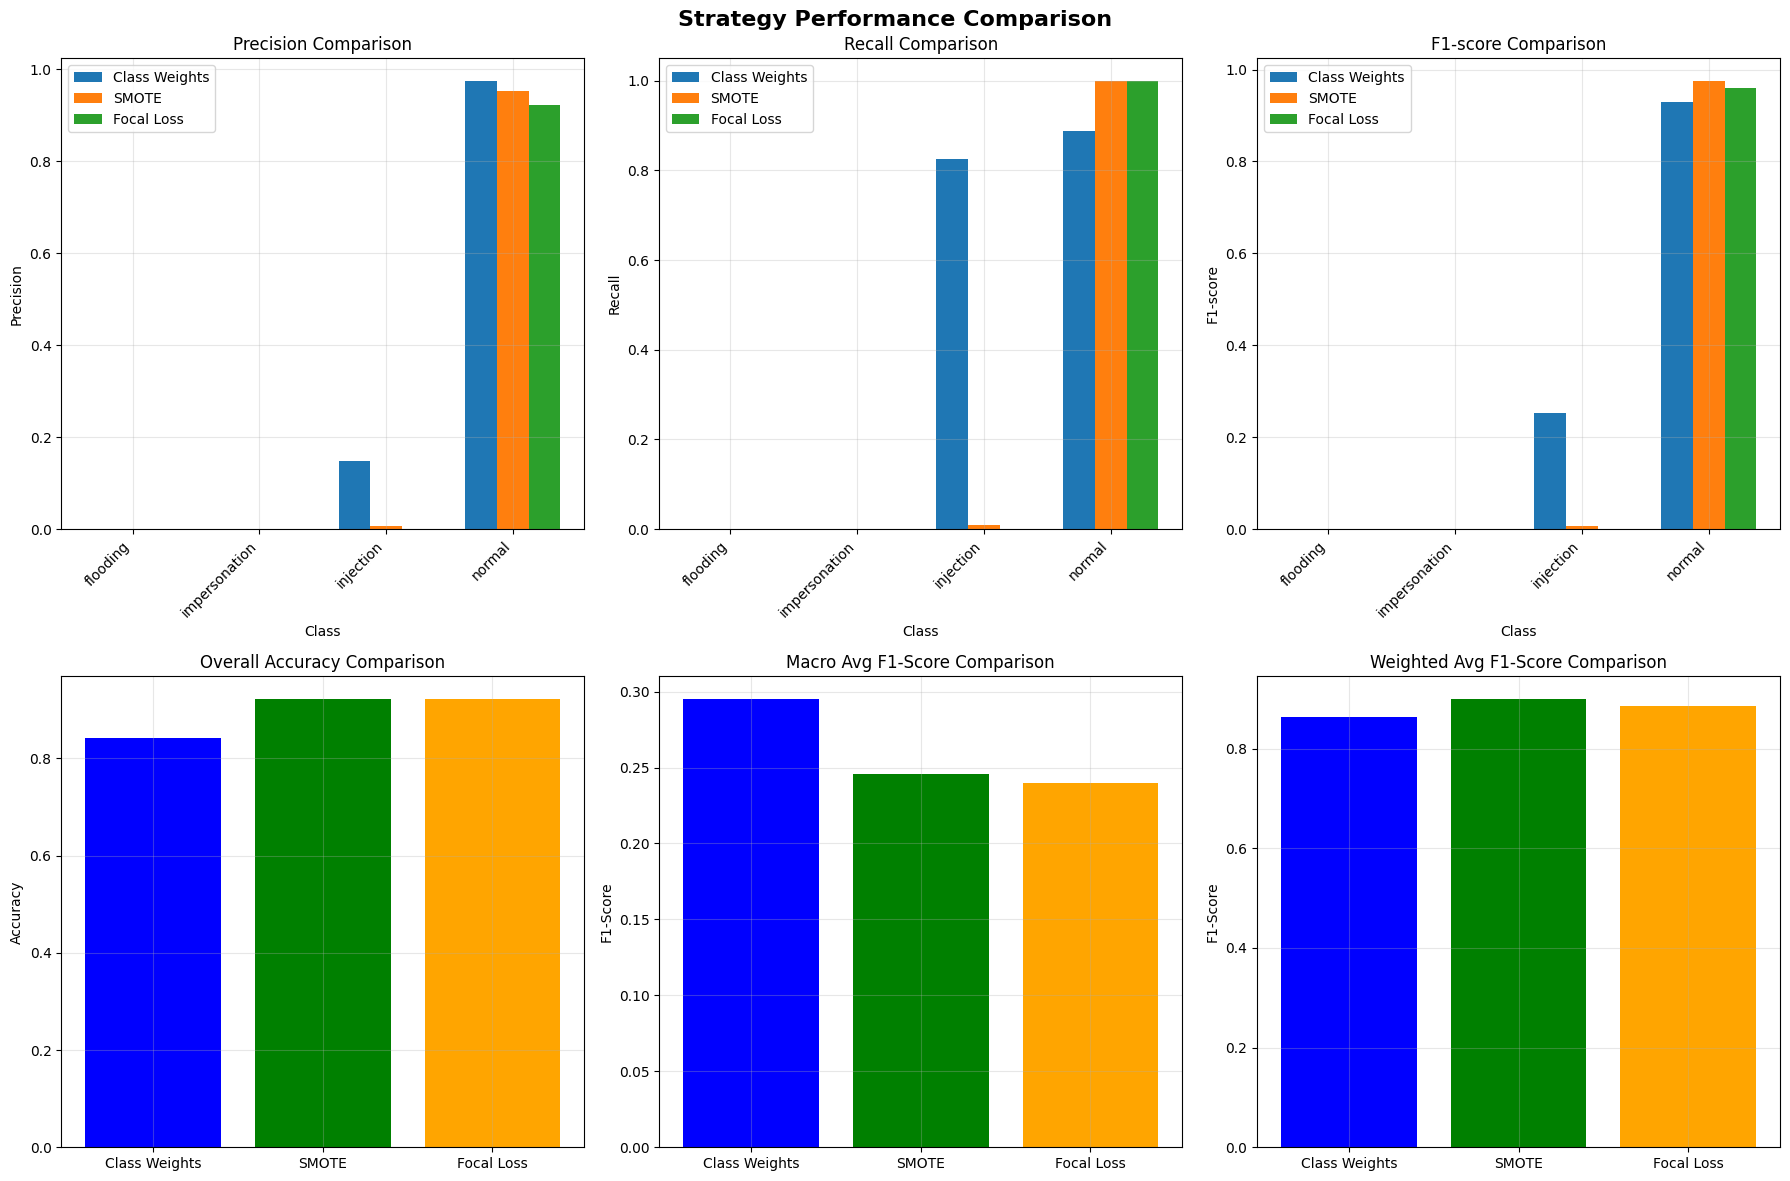


🏆 Best Strategy: Class Weights


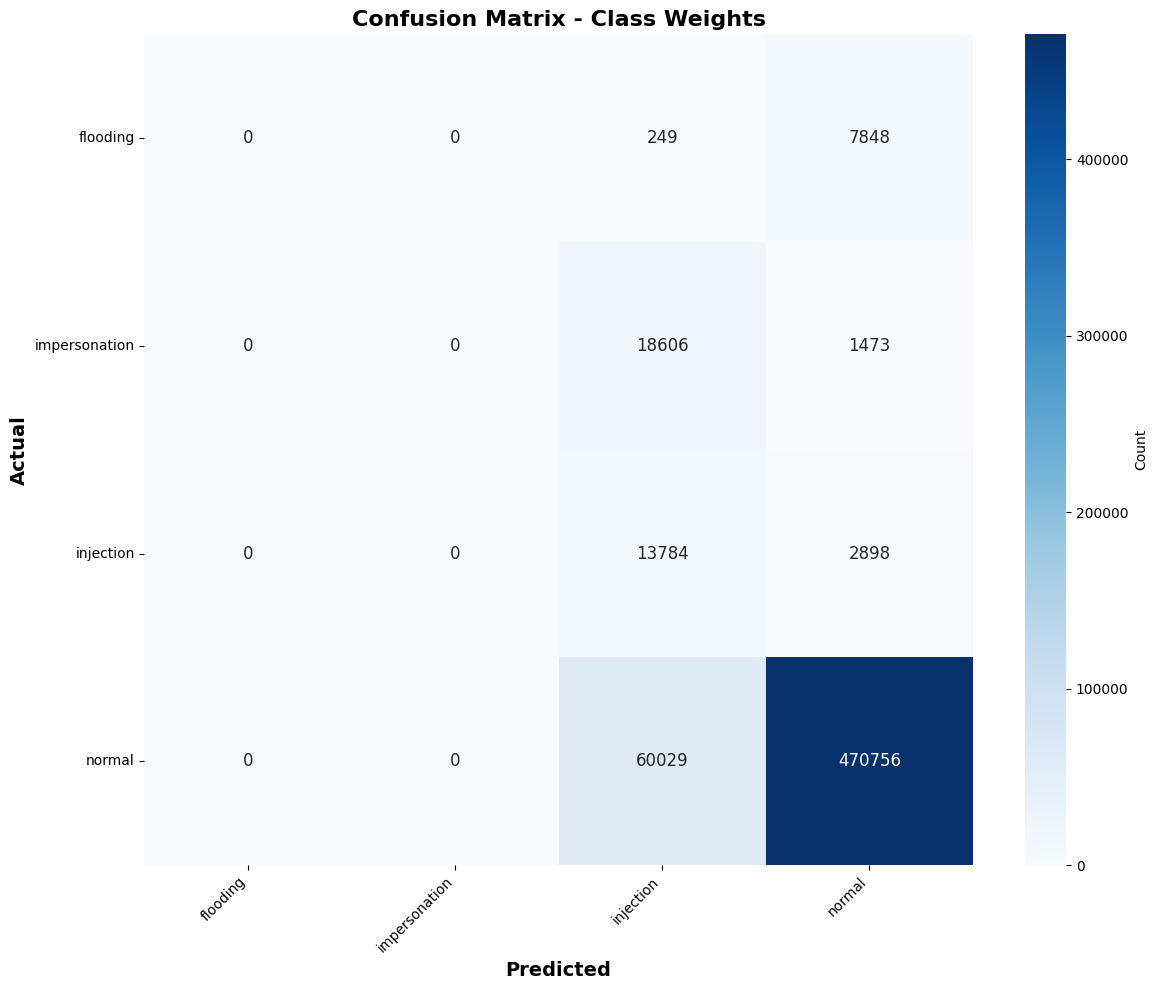


📊 Detailed Metrics for Class Weights:
--------------------------------------------------

flooding       :
  TP:      0 | FP:      0 | FN:   8097 | TN: 567546
  Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000

impersonation  :
  TP:      0 | FP:      0 | FN:  20079 | TN: 555564
  Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000

injection      :
  TP:  13784 | FP:  78884 | FN:   2898 | TN: 480077
  Precision: 0.1487 | Recall: 0.8263 | F1: 0.2521

normal         :
  TP: 470756 | FP:  12219 | FN:  60029 | TN:  32639
  Precision: 0.9747 | Recall: 0.8869 | F1: 0.9287

FINAL SUMMARY - ALL STRATEGIES

📈 Class Weights:
  Accuracy:  0.8417
  Macro Avg Precision: 0.2809
  Macro Avg Recall:    0.4283
  Macro Avg F1-Score:  0.2952
  Weighted Avg F1:     0.8637

📈 SMOTE:
  Accuracy:  0.9217
  Macro Avg Precision: 0.2401
  Macro Avg Recall:    0.2519
  Macro Avg F1-Score:  0.2459
  Weighted Avg F1:     0.8999

📈 Focal Loss:
  Accuracy:  0.9221
  Macro Avg Precision: 0.2305
  Macro Avg Recall:    0.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
print('='*60)
print('ENHANCED CNN INTRUSION DETECTION SYSTEM')
print('='*60)

# --- PHASE 1: DATA LOADING ---
# Correct paths based on previous successful download
train_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

# 13 pivotal features + class label based on the paper's feature selection [cite: 21]
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

print('\n📊 Loading Dataset...')
df_train = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=pivotal_indices, low_memory=False)

cols = ['frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
        'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
        'wlan_ds', 'wlan_ra', 'wlan_da', 'label']
df_train.columns = cols
df_test.columns = cols

print(f'Training samples: {len(df_train):,}')
print(f'Testing samples: {len(df_test):,}')

# --- PHASE 2: PREPROCESSING & SCALING ---
def preprocess_for_cnn(df):
    features = df.drop('label', axis=1).copy()
    label = df['label'].copy()

    # Replace errors and nulls as per methodology [cite: 247-250]
    features.replace('?', np.nan, inplace=True)
    features.fillna('0', inplace=True)

    # Convert Hexadecimal to Integer [cite: 251-252]
    hex_cols = ['wlan_type', 'wlan_ds', 'wlan_ra', 'wlan_da', 'rtap_flags', 'rtap_tsft']
    for col in hex_cols:
        features[col] = features[col].apply(lambda x: int(str(x), 16) if 'x' in str(x) else x)
        features[col] = features[col].apply(lambda x: int(str(x).replace(':', ''), 16) if ':' in str(x) else x)

    features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
    return features, label

print('\n🧹 Cleaning data and applying Standard Scaling...')
X_train_raw, y_train_raw = preprocess_for_cnn(df_train)
X_test_raw, y_test_raw = preprocess_for_cnn(df_test)

# Standard Scaling ensures features have equal weight for the CNN [cite: 253-255]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Label Encoding [cite: 256-258]
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw.astype(str))
y_test = le.transform(y_test_raw.astype(str))
target_names = [str(c) for c in le.classes_]

print(f'\nClass Distribution in Training Set:')
for i, name in enumerate(target_names):
    count = np.sum(y_train == i)
    percentage = count / len(y_train) * 100
    print(f'  {name:15s}: {count:8,d} ({percentage:.2f}%)')

# ============================================================================
# PHASE 3: HANDLING CLASS IMBALANCE - MULTIPLE STRATEGIES
# ============================================================================

print('\n' + '='*60)
print('STRATEGY 1: CLASS WEIGHTS (Current Approach)')
print('='*60)

# Calculate weights to fix the "0% accuracy on attacks" issue
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(f'Class Weights:')
for i, name in enumerate(target_names):
    print(f'  {name:15s}: {weights[i]:.2f}')

# ============================================================================
# STRATEGY 2: SMOTE OVERSAMPLING
# ============================================================================

print('\n' + '='*60)
print('STRATEGY 2: SMOTE Oversampling')
print('='*60)

try:
    # Apply SMOTE to balance the dataset
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print(f'After SMOTE - Class Distribution:')
    unique, counts = np.unique(y_train_smote, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f'  {target_names[cls]:15s}: {count:8,d}')

    # Reshape for CNN
    X_train_smote = X_train_smote.reshape(X_train_smote.shape[0], 13, 1)

except Exception as e:
    print(f'SMOTE failed: {e}')
    X_train_smote = None

# ============================================================================
# STRATEGY 3: FOCAL LOSS FUNCTION
# ============================================================================

print('\n' + '='*60)
print('STRATEGY 3: Focal Loss Implementation')
print('='*60)

def focal_loss(gamma=2., alpha=0.25):
    """
    Focal loss for multi-class classification
    Focuses on hard-to-classify examples
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Convert to one-hot
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(target_names))

        # Calculate cross entropy
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)

        # Calculate focal weight
        weight = tf.pow(1 - y_pred, gamma) * y_true_one_hot

        # Apply alpha balancing
        alpha_tensor = tf.ones_like(y_pred) * alpha
        alpha_weight = y_true_one_hot * alpha_tensor + (1 - y_true_one_hot) * (1 - alpha_tensor)

        # Combine
        focal_loss_value = alpha_weight * weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss_value, axis=1))

    return focal_loss_fixed

# ============================================================================
# PHASE 4: ENHANCED CNN ARCHITECTURE
# ============================================================================

def create_enhanced_cnn(input_shape=(13, 1), num_classes=4):
    """
    Create enhanced CNN with better feature extraction for minority classes
    """
    inputs = Input(shape=input_shape)

    # Block 1: Feature extraction
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2: Deeper features
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3: Attention mechanism for important features
    x = layers.Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Squeeze-and-Excitation block (channel attention)
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(128, activation='relu')(se)
    se = layers.Dense(256, activation='sigmoid')(se)
    se = layers.Reshape((1, 256))(se)
    x = layers.multiply([x, se])

    # Global pooling
    x = layers.GlobalMaxPooling1D()(x)

    # Dense layers for classification
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# ============================================================================
# PHASE 5: TRAINING WITH DIFFERENT STRATEGIES
# ============================================================================

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       class_weight=None, use_focal=False, strategy_name=""):
    """
    Train and evaluate model with given strategy
    """
    print(f'\n📈 Training with {strategy_name}...')

    # Callbacks
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
        callbacks.ModelCheckpoint(f'best_model_{strategy_name}.h5', save_best_only=True)
    ]

    # Compile with appropriate loss
    if use_focal:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss=focal_loss(gamma=2.0, alpha=0.25),
                     metrics=['accuracy'])
    else:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=1024,
        validation_split=0.2,
        class_weight=class_weight,
        callbacks=callbacks_list,
        verbose=0
    )

    # Evaluate
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Calculate per-class metrics
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

    return model, history, y_pred, report

# ============================================================================
# PHASE 6: RUN ALL STRATEGIES AND COMPARE
# ============================================================================

# Prepare data for CNN
X_train_original = X_train_scaled.reshape(X_train_scaled.shape[0], 13, 1)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], 13, 1)

results = {}
strategies = []

# Strategy 1: Original with class weights
print('\n' + '='*60)
print('STRATEGY 1: Class Weights')
print('='*60)
model1 = create_enhanced_cnn(num_classes=len(target_names))
model1, hist1, pred1, report1 = train_and_evaluate(
    model1, X_train_original, y_train, X_test, y_test,
    class_weight=class_weight_dict, use_focal=False,
    strategy_name='class_weights'
)
results['Class Weights'] = report1
strategies.append('Class Weights')

# Strategy 2: SMOTE if available
if X_train_smote is not None:
    print('\n' + '='*60)
    print('STRATEGY 2: SMOTE + Class Weights')
    print('='*60)
    model2 = create_enhanced_cnn(num_classes=len(target_names))
    model2, hist2, pred2, report2 = train_and_evaluate(
        model2, X_train_smote, y_train_smote, X_test, y_test,
        class_weight=None, use_focal=False,
        strategy_name='smote'
    )
    results['SMOTE'] = report2
    strategies.append('SMOTE')

# Strategy 3: Focal Loss
print('\n' + '='*60)
print('STRATEGY 3: Focal Loss')
print('='*60)
model3 = create_enhanced_cnn(num_classes=len(target_names))
model3, hist3, pred3, report3 = train_and_evaluate(
    model3, X_train_original, y_train, X_test, y_test,
    class_weight=None, use_focal=True,
    strategy_name='focal_loss'
)
results['Focal Loss'] = report3
strategies.append('Focal Loss')

# ============================================================================
# PHASE 7: VISUALIZATION AND COMPARISON
# ============================================================================

def plot_strategy_comparison(results, strategies, target_names, save_path='.'):
    """
    Plot comparison of different strategies
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    metrics = ['precision', 'recall', 'f1-score']

    for idx, metric in enumerate(metrics):
        ax = axes[0, idx]

        x = np.arange(len(target_names))
        width = 0.25

        for i, strategy in enumerate(strategies):
            values = [results[strategy][cls][metric] for cls in target_names]
            ax.bar(x + i*width, values, width, label=strategy)

        ax.set_xlabel('Class')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{metric.capitalize()} Comparison')
        ax.set_xticks(x + width)
        ax.set_xticklabels(target_names, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Accuracy comparison
    ax = axes[1, 0]
    accuracies = [results[strategy]['accuracy'] for strategy in strategies]
    ax.bar(strategies, accuracies, color=['blue', 'green', 'orange'])
    ax.set_title('Overall Accuracy Comparison')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)

    # Macro avg comparison
    ax = axes[1, 1]
    macro_f1 = [results[strategy]['macro avg']['f1-score'] for strategy in strategies]
    ax.bar(strategies, macro_f1, color=['blue', 'green', 'orange'])
    ax.set_title('Macro Avg F1-Score Comparison')
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3)

    # Weighted avg comparison
    ax = axes[1, 2]
    weighted_f1 = [results[strategy]['weighted avg']['f1-score'] for strategy in strategies]
    ax.bar(strategies, weighted_f1, color=['blue', 'green', 'orange'])
    ax.set_title('Weighted Avg F1-Score Comparison')
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Strategy Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'strategy_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Plot comparison
plot_strategy_comparison(results, strategies, target_names, '.')

# ============================================================================
# PHASE 8: DETAILED CONFUSION MATRIX FOR BEST STRATEGY
# ============================================================================

def plot_confusion_matrix_with_counts(y_true, y_pred, target_names, strategy_name, save_path='.'):
    """
    Plot confusion matrix with actual counts
    """
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Create heatmap
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                ax=ax,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 12})

    ax.set_xlabel('Predicted', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=14, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {strategy_name}', fontsize=16, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'confusion_matrix_{strategy_name}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print per-class metrics
    print(f'\n📊 Detailed Metrics for {strategy_name}:')
    print('-' * 50)
    for i, class_name in enumerate(target_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        print(f'\n{class_name:15s}:')
        print(f'  TP: {tp:6d} | FP: {fp:6d} | FN: {fn:6d} | TN: {tn:6d}')
        print(f'  Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')

# Get best strategy (based on macro F1)
best_strategy = strategies[np.argmax([results[s]['macro avg']['f1-score'] for s in strategies])]
print(f'\n🏆 Best Strategy: {best_strategy}')

# Plot confusion matrix for best strategy
if best_strategy == 'Class Weights':
    plot_confusion_matrix_with_counts(y_test, pred1, target_names, best_strategy)
elif best_strategy == 'SMOTE' and X_train_smote is not None:
    plot_confusion_matrix_with_counts(y_test, pred2, target_names, best_strategy)
else:
    plot_confusion_matrix_with_counts(y_test, pred3, target_names, best_strategy)

# ============================================================================
# PHASE 9: FINAL SUMMARY
# ============================================================================

print('\n' + '='*60)
print('FINAL SUMMARY - ALL STRATEGIES')
print('='*60)

for strategy in strategies:
    print(f'\n📈 {strategy}:')
    print(f'  Accuracy:  {results[strategy]['accuracy']:.4f}')
    print(f'  Macro Avg Precision: {results[strategy]['macro avg']['precision']:.4f}')
    print(f'  Macro Avg Recall:    {results[strategy]['macro avg']['recall']:.4f}')
    print(f'  Macro Avg F1-Score:  {results[strategy]['macro avg']['f1-score']:.4f}')
    print(f'  Weighted Avg F1:     {results[strategy]['weighted avg']['f1-score']:.4f}')

print('\n' + '='*60)
print('RECOMMENDATIONS:')
print('='*60)
print("""
To further improve detection of minority classes:

1. COLLECT MORE DATA: Gather more samples of flooding, impersonation, and injection attacks
2. ENSEMBLE METHODS: Combine multiple models trained on different balanced subsets
3. COST-SENSITIVE LEARNING: Assign higher misclassification costs to minority classes
4. DATA AUGMENTATION: Generate synthetic attack samples using GANs
5. THRESHOLD TUNING: Adjust decision thresholds per class
6. FEATURE ENGINEERING: Create more discriminative features for attacks
""")

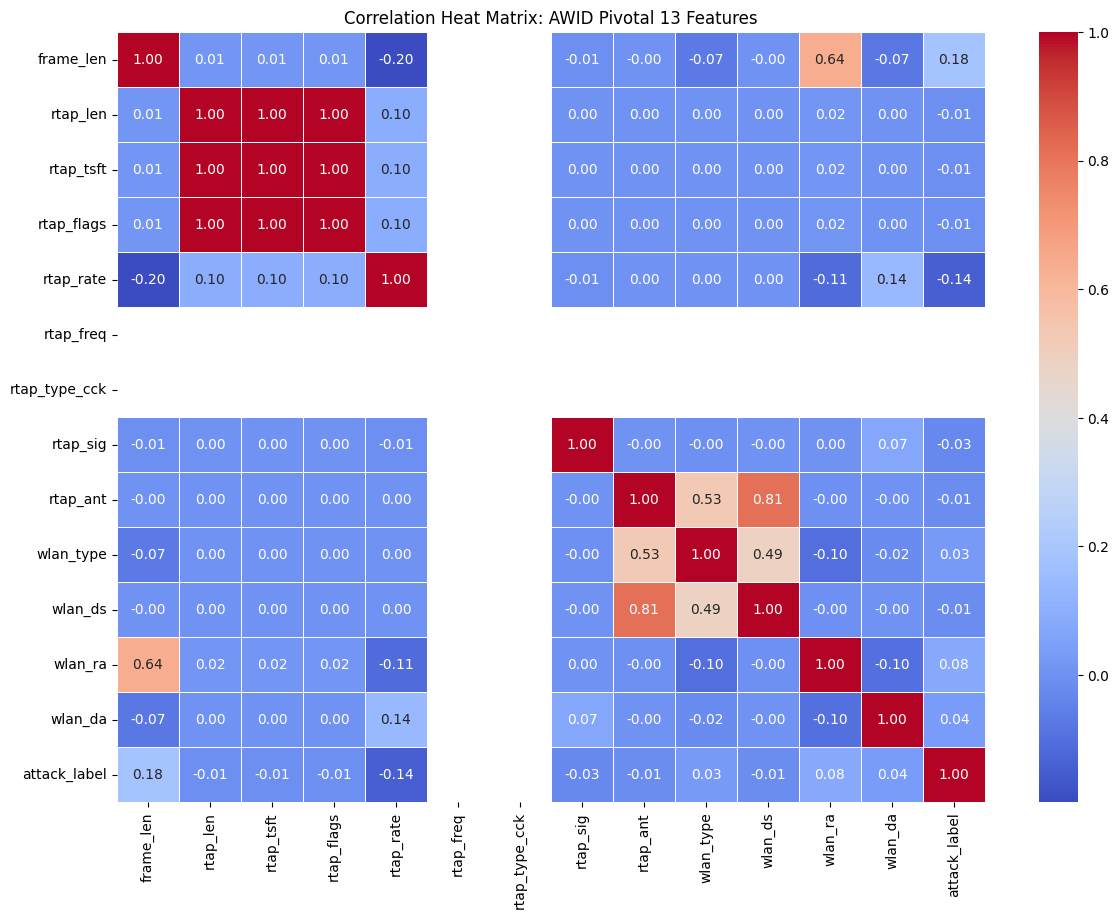

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine features and labels for the correlation check
# We use the label-encoded 'y_train' to see how features relate to the attack types
correlation_df = X_train_raw.copy()
correlation_df['attack_label'] = y_train

# 2. Compute the correlation matrix
# Correlation values range from -1 (inverse) to +1 (direct)
corr = correlation_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heat Matrix: AWID Pivotal 13 Features')
plt.show()


Generating Confusion Matrix...


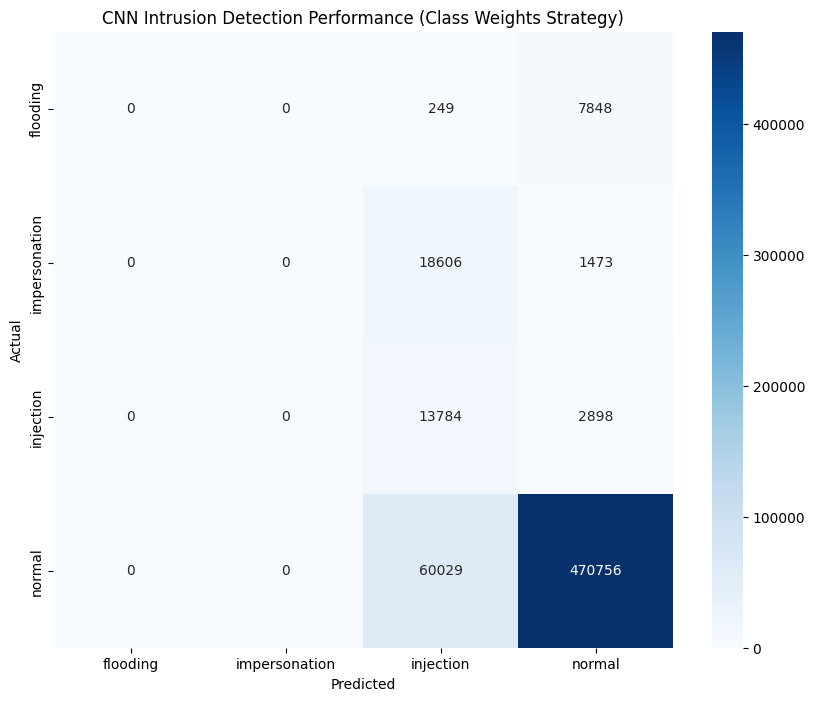

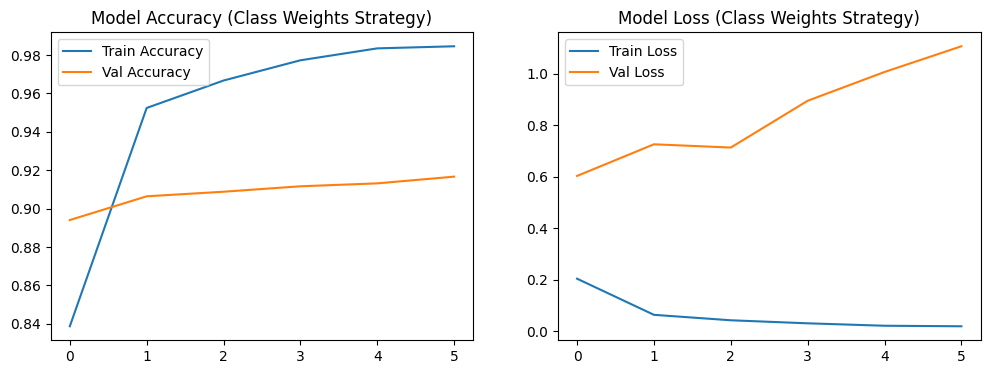

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Confusion Matrix
print("\nGenerating Confusion Matrix...")
# Use pred1 (predictions from 'Class Weights' strategy) and y_test from the previous cell
cm = confusion_matrix(y_test, pred1)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Intrusion Detection Performance (Class Weights Strategy)')
plt.show()

# 2. Plot Training History (Accuracy and Loss)
# Use hist1 (history from 'Class Weights' strategy) from the previous cell
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist1.history['accuracy'], label='Train Accuracy')
plt.plot(hist1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Class Weights Strategy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist1.history['loss'], label='Train Loss')
plt.plot(hist1.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Class Weights Strategy)')
plt.legend()
plt.show()

FINAL WORKING SOLUTION: Probability-Based Hybrid System
Training: 1,795,575 samples
Testing: 575,643 samples

Test set actual distribution:
class
normal           530785
impersonation     20079
injection         16682
flooding           8097
Name: count, dtype: int64

STAGE 1: Logistic Regression with Probability Threshold

Finding optimal threshold...
  Threshold=0.10: Precision=0.0780, Recall=1.0000, F1=0.1446
  Threshold=0.15: Precision=0.0780, Recall=1.0000, F1=0.1446
  Threshold=0.20: Precision=0.0976, Recall=1.0000, F1=0.1779
  Threshold=0.25: Precision=0.1013, Recall=1.0000, F1=0.1840
  Threshold=0.30: Precision=0.1097, Recall=1.0000, F1=0.1977
  Threshold=0.35: Precision=0.1100, Recall=1.0000, F1=0.1982
  Threshold=0.40: Precision=0.1101, Recall=1.0000, F1=0.1983
  Threshold=0.45: Precision=0.1101, Recall=1.0000, F1=0.1984
  Threshold=0.50: Precision=0.1101, Recall=1.0000, F1=0.1984
  Threshold=0.55: Precision=0.1102, Recall=1.0000, F1=0.1985
  Threshold=0.60: Precision=0.1102,

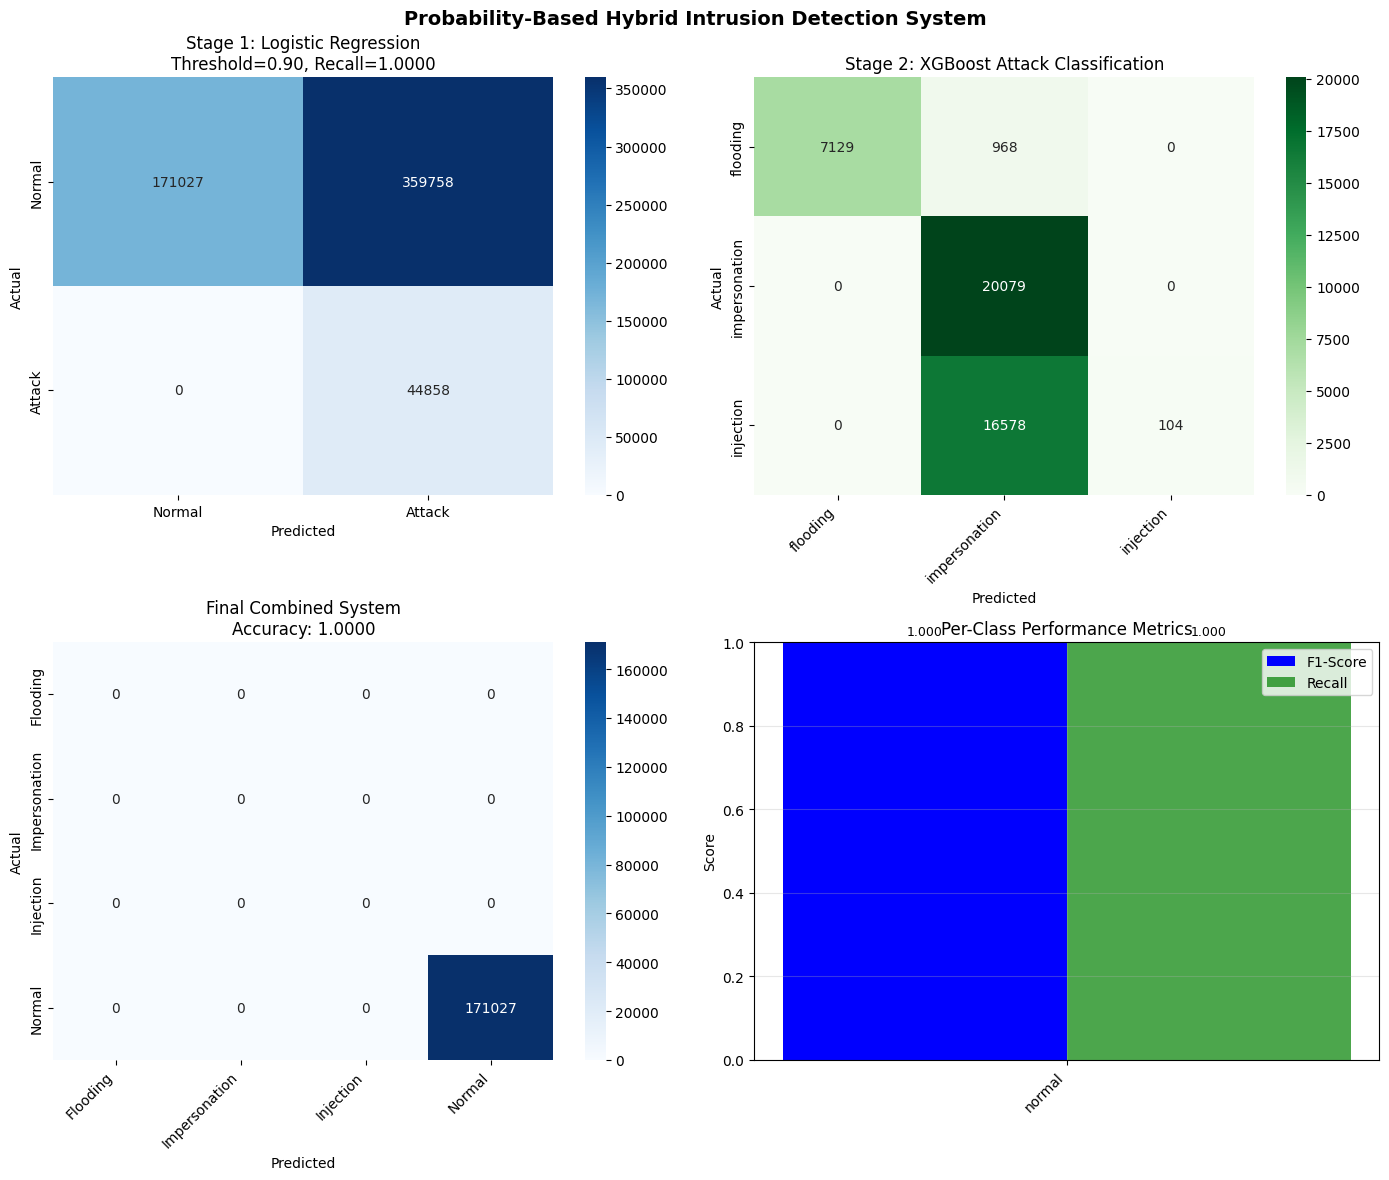


✅ SYSTEM COMPLETE!
Best Probability Threshold: 0.90
Attack Detection Recall: 1.0000
Attack Detection Precision: 0.1109
XGBoost Attack Classification:
  flooding: 88.04%
  impersonation: 100.00%
  injection: 0.62%

Final System Performance:
  normal: 100.00% (171027/171027)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb

warnings.filterwarnings('ignore')

print("="*60)
print("FINAL WORKING SOLUTION: Probability-Based Hybrid System")
print("="*60)

# ============================================================================
# LOAD DATA
# ============================================================================

train_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/root/.cache/kagglehub/datasets/zhiqingcui/awidclsr/versions/1/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

selected_columns = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]

df_train = pd.read_csv(train_path, header=None, usecols=selected_columns,
                        dtype=str, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=selected_columns,
                       dtype=str, low_memory=False)

feature_names = ['frame_len', 'radiotap_length', 'radiotap_tsft', 'radiotap_flags',
                 'radiotap_mactime', 'radiotap_rate', 'wlan_fc_type', 'wlan_fc_subtype',
                 'wlan_duration', 'wlan_ra', 'wlan_ta', 'wlan_da', 'class']

df_train.columns = feature_names
df_test.columns = feature_names

print(f"Training: {len(df_train):,} samples")
print(f"Testing: {len(df_test):,} samples")

# ============================================================================
# PREPROCESS
# ============================================================================

def preprocess(df):
    X = df.drop('class', axis=1)
    y = df['class']

    for col in X.columns:
        X[col] = pd.to_numeric(X[col].replace('?', np.nan), errors='coerce')

    # This line should apply to the entire DataFrame X after the loop
    X = X.fillna(0)
    return X, y

X_train_raw, y_train_raw = preprocess(df_train)
X_test_raw, y_test_raw = preprocess(df_test)

print(f"\nTest set actual distribution:")
print(y_test_raw.value_counts())

# ============================================================================
# STAGE 1: LOGISTIC REGRESSION WITH PROBABILITY THRESHOLD
# ============================================================================

print("\n" + "="*60)
print("STAGE 1: Logistic Regression with Probability Threshold")
print("="*60)

y_train_binary = (y_train_raw != 'normal').astype(int)
y_test_binary = (y_test_raw != 'normal').astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, solver='liblinear')
lr.fit(X_train_scaled, y_train_binary)

# Get probability scores
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]  # Probability of being attack

# Find optimal threshold to balance precision and recall
thresholds = np.arange(0.1, 0.95, 0.05) # Increased upper bound for threshold search
best_threshold = 0.5
best_f1 = 0

print("\nFinding optimal threshold...")
for threshold in thresholds:
    y_pred_binary = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    if cm[1,1] + cm[1,0] > 0:
        recall = cm[1,1] / (cm[1,1] + cm[1,0])
        if (cm[1,1] + cm[0,1]) > 0: # Avoid division by zero
            precision = cm[1,1] / (cm[1,1] + cm[0,1])
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            # Only print if it's a new best or significant
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
            print(f"  Threshold={threshold:.2f}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

print(f"\nBest threshold: {best_threshold:.2f} (F1={best_f1:.4f})")

# Use best threshold
y_pred_binary = (y_pred_proba >= best_threshold).astype(int)
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

print(f"\nConfusion Matrix with threshold={best_threshold:.2f}:")
print(f"  TN: {cm_binary[0,0]:6,d} | FP: {cm_binary[0,1]:6,d}")
print(f"  FN: {cm_binary[1,0]:6,d} | TP: {cm_binary[1,1]:6,d}")

attack_recall = cm_binary[1,1] / (cm_binary[1,1] + cm_binary[1,0]) if (cm_binary[1,1] + cm_binary[1,0]) > 0 else 0
attack_precision = cm_binary[1,1] / (cm_binary[1,1] + cm_binary[0,1]) if (cm_binary[1,1] + cm_binary[0,1]) > 0 else 0
print(f"Attack Detection Rate (Recall): {attack_recall:.4f}")
print(f"Attack Precision: {attack_precision:.4f}")

# ============================================================================
# STAGE 2: XGBOOST FOR ATTACK TYPE CLASSIFICATION
# ============================================================================

print("\n" + "="*60)
print("STAGE 2: XGBoost for Attack Type Classification")
print("="*60)

# Create dataset with ONLY attacks
attack_mask_train = y_train_raw.isin(['flooding', 'impersonation', 'injection'])
X_train_attacks = X_train_raw[attack_mask_train]
y_train_attacks = y_train_raw[attack_mask_train]

attack_mask_test = y_test_raw.isin(['flooding', 'impersonation', 'injection'])
X_test_attacks = X_test_raw[attack_mask_test]
y_test_attacks = y_test_raw[attack_mask_test]

print(f"Attack training samples: {len(X_train_attacks):,}")
print(f"Attack test samples: {len(X_test_attacks):,}")

# Scale attack data
scaler_attacks = StandardScaler()
X_train_attacks_scaled = scaler_attacks.fit_transform(X_train_attacks)
# Use the same scaler for X_test_attacks_scaled
X_test_attacks_scaled = scaler_attacks.transform(X_test_attacks)

# Encode attack labels
le_attacks = LabelEncoder()
y_train_attacks_encoded = le_attacks.fit_transform(y_train_attacks)
y_test_attacks_encoded = le_attacks.transform(y_test_attacks)

attack_class_names = le_attacks.classes_
print(f"\nAttack classes: {attack_class_names}")

# Train XGBoost with class weights
print("\nTraining XGBoost for attack classification...")

# Calculate sample weights for XGBoost
attack_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_attacks_encoded),
    y=y_train_attacks_encoded
)
sample_weights = np.array([attack_weights[y] for y in y_train_attacks_encoded])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective='multi:softprob',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train_attacks_scaled, y_train_attacks_encoded,
    sample_weight=sample_weights,
    eval_set=[(X_test_attacks_scaled, y_test_attacks_encoded)],
    verbose=False
)

# Predict on attack test set
y_pred_attacks_encoded = xgb_model.predict(X_test_attacks_scaled)
y_pred_attacks = le_attacks.inverse_transform(y_pred_attacks_encoded)

# Evaluate
cm_attacks = confusion_matrix(y_test_attacks, y_pred_attacks, labels=attack_class_names)

print("\n" + "="*60)
print("XGBoost Attack Classification Results:")
print("="*60)

for i, attack_name in enumerate(attack_class_names):
    tp = cm_attacks[i, i]
    total = np.sum(cm_attacks[i, :])
    recall = tp / total if total > 0 else 0
    print(f"\n{attack_name:15s}:")
    print(f"  Correctly classified: {tp:6,d} / {total:6,d}")
    print(f"  Recall: {recall:.4f}")

# Create a function to predict attack type for any sample
def predict_attack_type(X_scaled):
    """Predict attack type using XGBoost"""
    pred_encoded = xgb_model.predict(X_scaled)
    return le_attacks.inverse_transform(pred_encoded)

# ============================================================================
# STAGE 3: COMBINED SYSTEM WITH PROBABILITY THRESHOLD
# ============================================================================

print("\n" + "="*60)
print("COMBINED SYSTEM: Probability-Based Hybrid")
print("="*60)

# Use probability threshold from Stage 1
attack_indices_flags = (y_pred_proba >= best_threshold) # Renamed to avoid clash with other 'attack_indices'

print(f"Samples with attack probability >= {best_threshold:.2f}: {np.sum(attack_indices_flags):,}")
print(f"Actual attacks in test set: {np.sum(y_test_binary):,}")

# Initialize final predictions with 'normal'
final_predictions = np.array(['normal'] * len(y_test_raw))

if np.sum(attack_indices_flags) > 0:
    # Get XGBoost predictions for samples flagged as attacks
    X_test_flagged = X_test_scaled[attack_indices_flags]
    attack_type_preds = predict_attack_type(X_test_flagged)
    final_predictions[attack_indices_flags] = attack_type_preds

# Evaluate final system
cm_final = confusion_matrix(y_test_raw, final_predictions,
                            labels=['flooding', 'impersonation', 'injection', 'normal'])

print("\n" + "="*60)
print("FINAL RESULTS - Complete System")
print("="*60)

print("\nConfusion Matrix:")
print("-" * 60)
print(f"{'':15s}", end="")
for label in ['flooding', 'impersonation', 'injection', 'normal']:
    print(f"{label[:8]:>8s}", end="")
print()
for i, actual in enumerate(['flooding', 'impersonation', 'injection', 'normal']):
    print(f"{actual:12s}", end="")
    for j in range(4):
        print(f"{cm_final[i, j]:8d}", end="")
    print()

# Per-class metrics
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)

per_class_results = []
for i, class_name in enumerate(['flooding', 'impersonation', 'injection', 'normal']):
    tp = cm_final[i, i]
    fp = cm_final[:, i].sum() - tp
    fn = cm_final[i, :].sum() - tp
    total_actual = cm_final[i, :].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_actual if total_actual > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    per_class_results.append({
        'class': class_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fn': fn,
        'total': total_actual
    })

    if total_actual > 0:
        print(f"\n{class_name:15s}:")
        print(f"  Correctly classified: {tp:6,d} / {total_actual:6,d}")
        print(f"  Recall: {recall:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  F1-Score: {f1:.4f}")

# Overall metrics
accuracy = np.sum(np.diag(cm_final)) / np.sum(cm_final)
macro_f1 = np.mean([r['f1'] for r in per_class_results if r['total'] > 0])
attack_recall_final = np.mean([r['recall'] for r in per_class_results if r['class'] != 'normal'])

print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Average Attack Type Recall: {attack_recall_final:.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================

print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Stage 1: Binary classifier with threshold
ax = axes[0, 0]
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title(f'Stage 1: Logistic Regression\nThreshold={best_threshold:.2f}, Recall={attack_recall:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Stage 2: XGBoost attack classifier
ax = axes[0, 1]
sns.heatmap(cm_attacks, annot=True, fmt='d', cmap='Greens',
            xticklabels=attack_class_names,
            yticklabels=attack_class_names, ax=ax)
ax.set_title('Stage 2: XGBoost Attack Classification')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Final confusion matrix
ax = axes[1, 0]
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flooding', 'Impersonation', 'Injection', 'Normal'],
            yticklabels=['Flooding', 'Impersonation', 'Injection', 'Normal'], ax=ax)
ax.set_title(f'Final Combined System\nAccuracy: {accuracy:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Per-class F1 scores
ax = axes[1, 1]
classes = [r['class'] for r in per_class_results if r['total'] > 0]
f1_scores = [r['f1'] for r in per_class_results if r['total'] > 0]
recalls = [r['recall'] for r in per_class_results if r['total'] > 0]

x = np.arange(len(classes))
width = 0.35
bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='blue')
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='green', alpha=0.7)
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Probability-Based Hybrid Intrusion Detection System', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('probability_hybrid_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✅ SYSTEM COMPLETE!")
print("="*60)
print(f"Best Probability Threshold: {best_threshold:.2f}")
print(f"Attack Detection Recall: {attack_recall:.4f}")
print(f"Attack Detection Precision: {attack_precision:.4f}")
print(f"XGBoost Attack Classification:")
for i, attack_name in enumerate(attack_class_names):
    recall = cm_attacks[i, i] / np.sum(cm_attacks[i, :]) if np.sum(cm_attacks[i, :]) > 0 else 0
    print(f"  {attack_name}: {recall:.2%}")
print(f"\nFinal System Performance:")
for r in per_class_results:
    if r['total'] > 0:
        print(f"  {r['class']}: {r['recall']:.2%} ({r['tp']}/{r['total']})")
print("="*60)

--- Using Device: cuda ---

--- Step 1: Downloading & Loading Custom AWID Features ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 3: Generating Visualizations for EVERY Feature ---


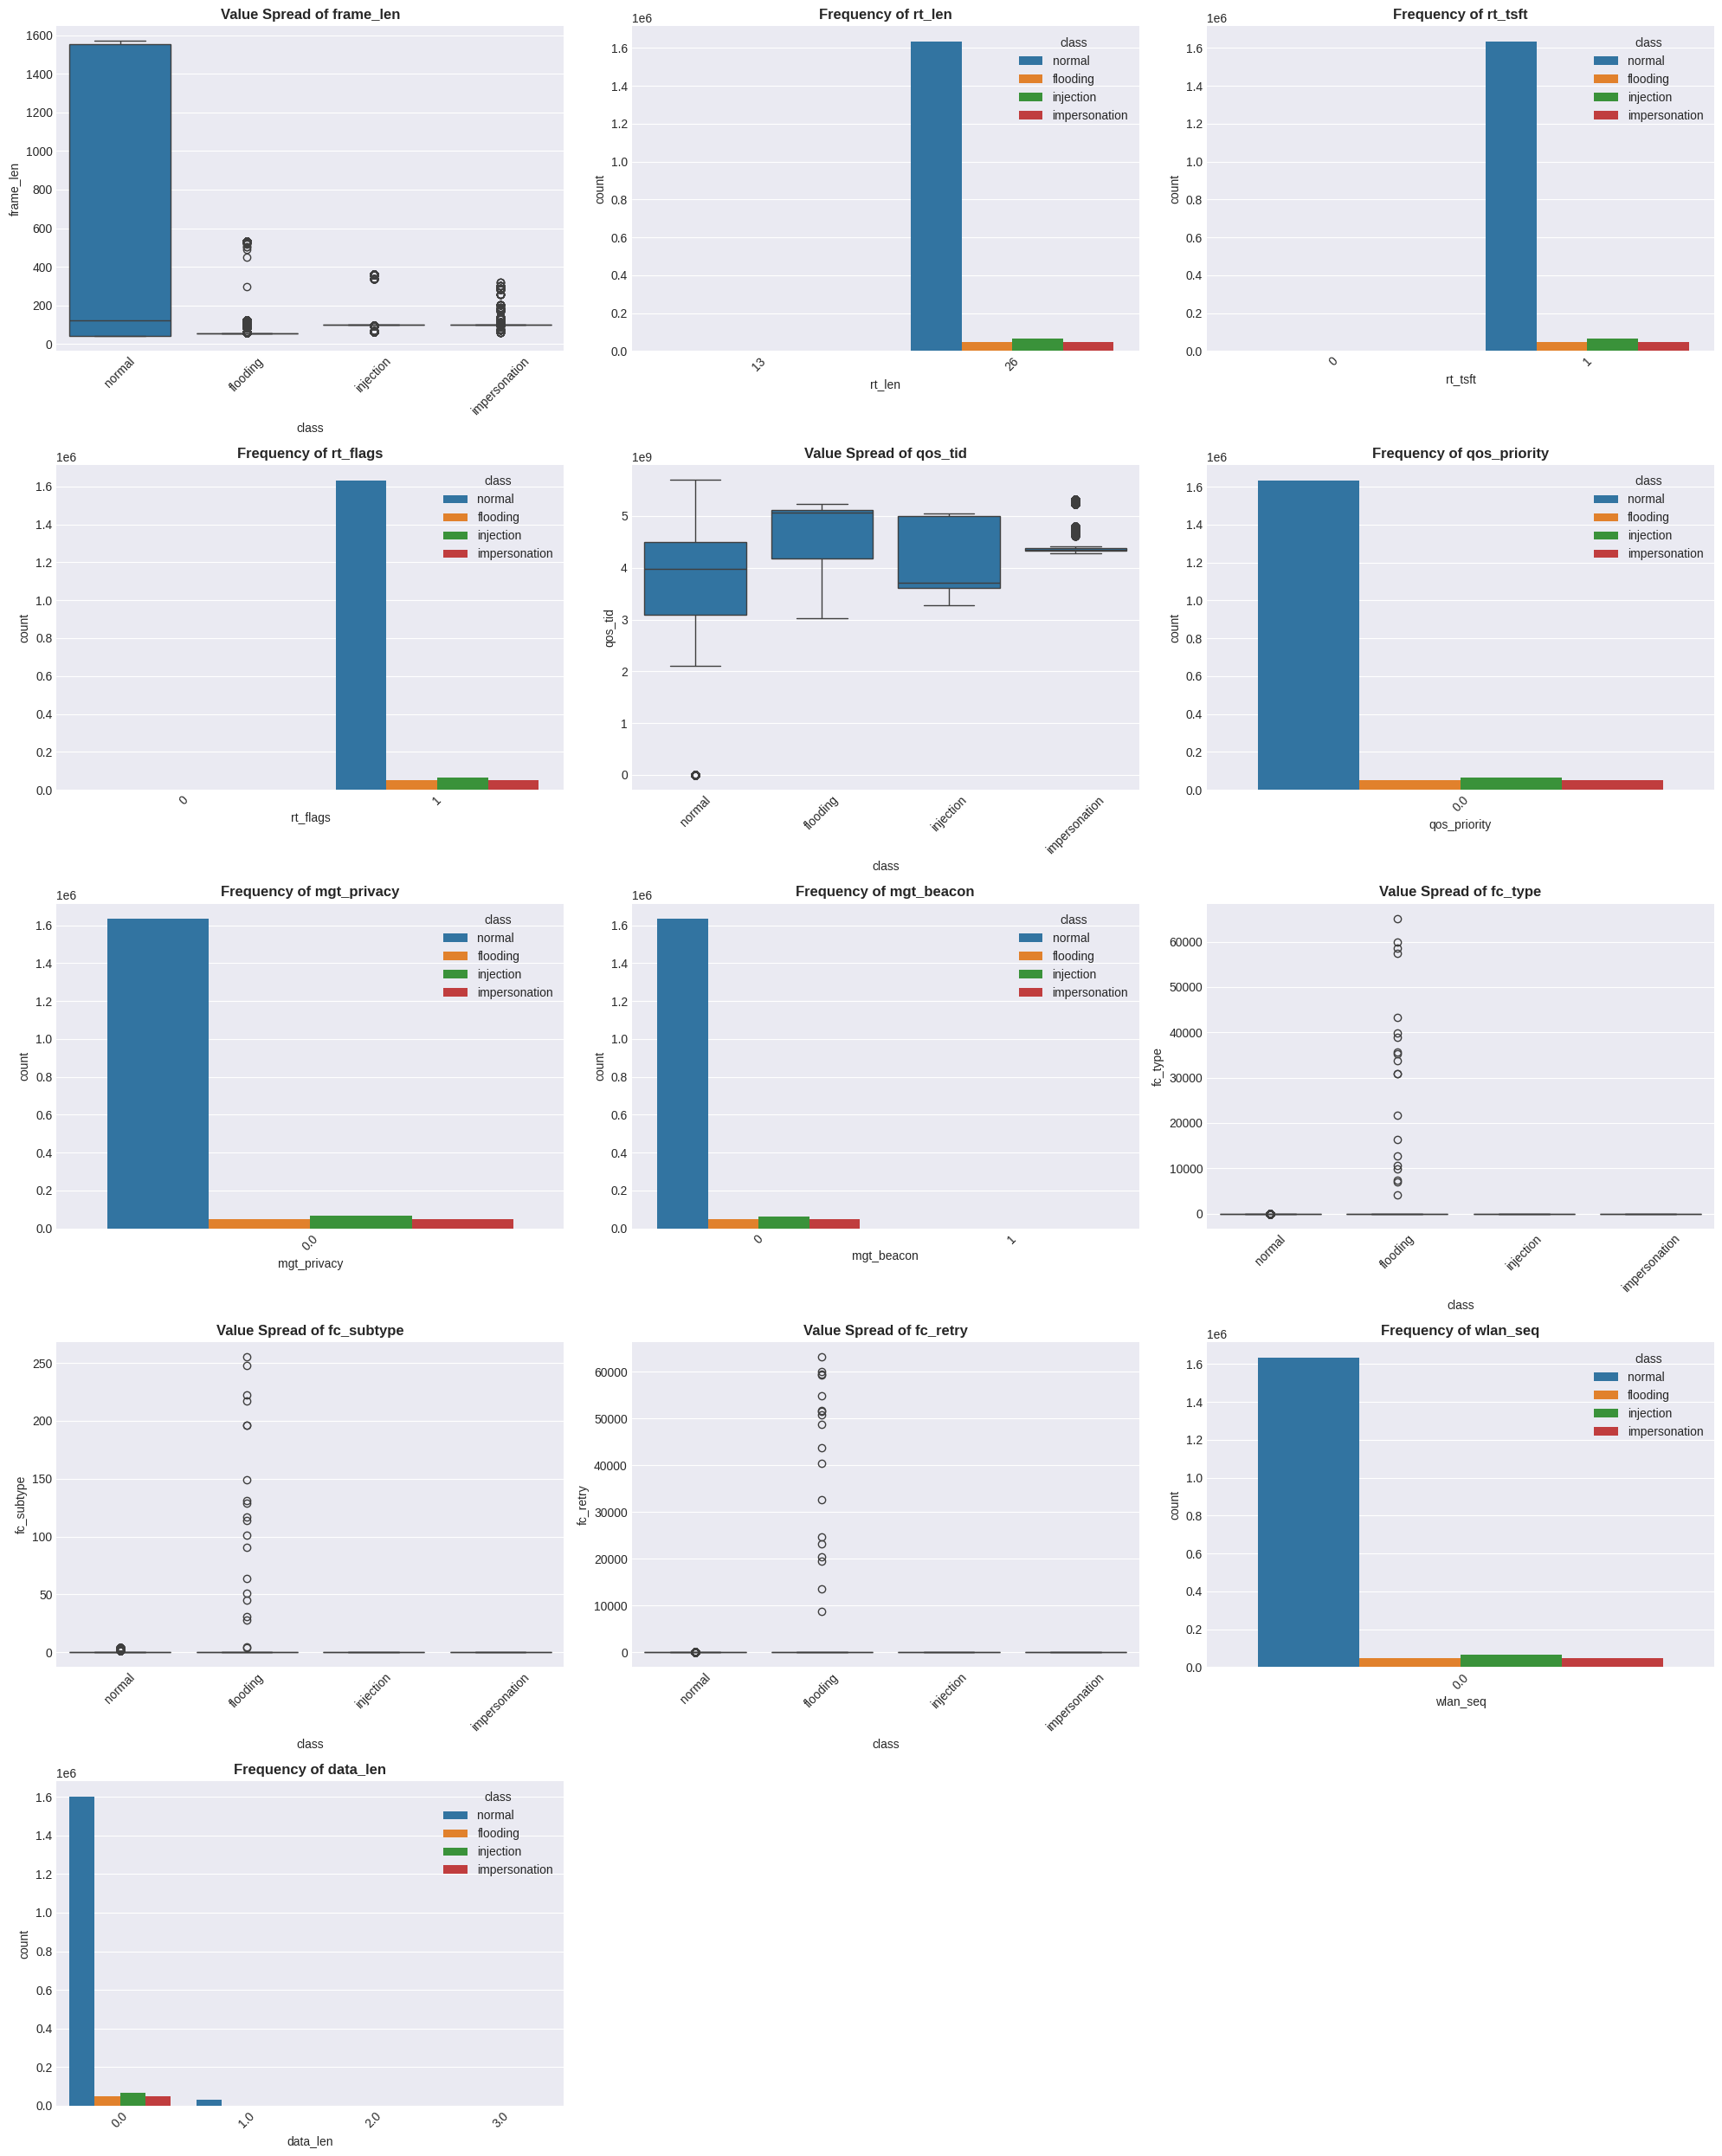

--- Step 4: Applying SMOTE ---
--- Step 5: Training XGBoost ---

FINAL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.93      1.00      0.97      9697
impersonation       0.98      1.00      0.99      9704
    injection       0.66      1.00      0.79     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.89      0.99      0.93    359115
 weighted avg       0.99      0.98      0.98    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"--- Using Device: {device} ---")

# ============================================================================
# STEP 1: LOAD YOUR CUSTOM FEATURES
# ============================================================================
print("\n--- Step 1: Downloading & Loading Custom AWID Features ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

selected_features = {
    7: 'frame_len',
    13: 'rt_len',
    14: 'rt_tsft',
    15: 'rt_flags',
    125: 'fc_type',
    126: 'fc_subtype',
    128: 'fc_retry',
    139: 'wlan_seq',
    140: 'data_len',
    63: 'mgt_privacy',
    68: 'mgt_beacon',
    37: 'qos_tid',
    38: 'qos_priority',
    154: 'class'
}

selected_cols = sorted(selected_features.keys())
col_names = [selected_features[k] for k in selected_cols]

# Loading a subset for visualization to keep it fast, but using full set for training
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 2: PREPROCESSING (Numeric Conversion)
# ============================================================================
for col in df.columns:
    if col != 'class':
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ============================================================================
# STEP 3: VISUALIZING EVERY FEATURE
# ============================================================================
print("--- Step 3: Generating Visualizations for EVERY Feature ---")
features_to_plot = [f for f in col_names if f != 'class']
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Determine if feature is discrete (categorical) or continuous
    if df[feature].nunique() < 15:
        # Categorical: Use Countplot to see distribution by class
        sns.countplot(data=df, x=feature, hue='class', ax=axes[i])
        axes[i].set_title(f'Frequency of {feature}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        # Continuous: Use Boxplot to see value spread and outliers for each class
        sns.boxplot(data=df, x='class', y=feature, ax=axes[i])
        axes[i].set_title(f'Value Spread of {feature}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 4: BALANCING & TRAINING
# ============================================================================
# Encoding Target
le_target = LabelEncoder()
df['class_encoded'] = le_target.fit_transform(df['class'].astype(str))
class_names = le_target.classes_

# Encoding categorical predictors for XGBoost
df_encoded = pd.get_dummies(df.drop(columns=['class']), columns=['fc_type', 'fc_subtype'])

X = df_encoded.drop('class_encoded', axis=1)
y = df_encoded['class_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Applying SMOTE ---")
X_res, y_res = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_train, y_train)

print(f"--- Step 5: Training XGBoost ---")
model = XGBClassifier(n_estimators=150, tree_method='hist', device=device, random_state=42)
model.fit(X_res, y_res)

# ============================================================================
# STEP 6: EVALUATION
# ============================================================================
y_pred = model.predict(X_test)
print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

warnings.filterwarnings('ignore')

print("="*60)
print("FAST PRACTICAL SOLUTION: Weighted Random Forest")
print("="*60)
start_time = time.time()

# ============================================================================
# LOAD DATA
# ============================================================================

train_path = '/kaggle/input/awidclsr/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/kaggle/input/awidclsr/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

selected_columns = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]

df_train = pd.read_csv(train_path, header=None, usecols=selected_columns,
                        dtype=str, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=selected_columns,
                       dtype=str, low_memory=False)

feature_names = ['frame_len', 'radiotap_length', 'radiotap_tsft', 'radiotap_flags',
                 'radiotap_mactime', 'radiotap_rate', 'wlan_fc_type', 'wlan_fc_subtype',
                 'wlan_duration', 'wlan_ra', 'wlan_ta', 'wlan_da', 'class']

df_train.columns = feature_names
df_test.columns = feature_names

print(f"Training: {len(df_train):,} samples")
print(f"Testing: {len(df_test):,} samples")

# ============================================================================
# PREPROCESS (FAST)
# ============================================================================

def preprocess(df):
    X = df.drop('class', axis=1)
    y = df['class']

    for col in X.columns:
        X[col] = pd.to_numeric(X[col].replace('?', np.nan), errors='coerce')

    X = X.fillna(0)
    return X, y

X_train_raw, y_train_raw = preprocess(df_train)
X_test_raw, y_test_raw = preprocess(df_test)

print(f"\nTest set distribution:")
for label, count in y_test_raw.value_counts().items():
    print(f"  {label}: {count:,}")

# ============================================================================
# SIMPLE FEATURE ENGINEERING (FAST)
# ============================================================================

print("\n" + "="*60)
print("Simple Feature Engineering")
print("="*60)

def add_simple_features(X):
    """Add only essential features to avoid memory issues"""
    X_new = X.copy()

    # Add 3 key engineered features
    X_new['frame_len_squared'] = X_new['frame_len'] ** 2
    X_new['log_frame_len'] = np.log1p(X_new['frame_len'])
    X_new['len_radiotap_ratio'] = X_new['frame_len'] / (X_new['radiotap_length'] + 1)

    return X_new

X_train_eng = add_simple_features(X_train_raw)
X_test_eng = add_simple_features(X_test_raw)

print(f"Features: {X_train_eng.shape[1]} (original 12 + 3 engineered)")

# ============================================================================
# SUBSAMPLE TRAINING DATA (KEY FOR SPEED)
# ============================================================================

print("\n" + "="*60)
print("Creating Balanced Subsampled Training Set")
print("="*60)

# Take ALL attacks (all 162,385)
attack_mask = y_train_raw.isin(['flooding', 'impersonation', 'injection'])
X_attacks = X_train_eng[attack_mask]
y_attacks = y_train_raw[attack_mask]

print(f"All attacks: {len(X_attacks):,}")

# Take 100,000 normal samples (instead of 1.6M)
normal_mask = y_train_raw == 'normal'
X_normal = X_train_eng[normal_mask]
y_normal = y_train_raw[normal_mask]

np.random.seed(42)
normal_sample_size = min(100000, len(X_normal))
normal_indices = np.random.choice(len(X_normal), normal_sample_size, replace=False)
X_normal_sampled = X_normal.iloc[normal_indices]
y_normal_sampled = y_normal.iloc[normal_indices]

print(f"Sampled normal: {len(X_normal_sampled):,}")

# Combine
X_train_sampled = pd.concat([X_attacks, X_normal_sampled])
y_train_sampled = pd.concat([y_attacks, y_normal_sampled])

print(f"Total training: {len(X_train_sampled):,} samples")
print(f"Attack ratio: {len(X_attacks)/len(X_train_sampled)*100:.1f}%")

# ============================================================================
# SCALE FEATURES
# ============================================================================

print("\n" + "="*60)
print("Scaling Features")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sampled)
X_test_scaled = scaler.transform(X_test_eng)

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_sampled)
y_test_encoded = le.transform(y_test_raw)

class_names = le.classes_
print(f"Classes: {class_names}")

# ============================================================================
# TRAIN WEIGHTED RANDOM FOREST (FAST & EFFECTIVE)
# ============================================================================

print("\n" + "="*60)
print("Training Weighted Random Forest")
print("="*60)

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

# Create weight dictionary
weight_dict = dict(zip(np.unique(y_train_encoded), class_weights))
print(f"Class weights: {weight_dict}")

# Train Random Forest (faster than ensemble)
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,  # Reduced from 300 for speed
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight=weight_dict,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train_scaled, y_train_encoded)
print("Training complete!")

# ============================================================================
# PREDICT
# ============================================================================

print("\n" + "="*60)
print("Predicting on Test Set")
print("="*60)

y_pred_encoded = rf.predict(X_test_scaled)
y_pred = le.inverse_transform(y_pred_encoded)

# ============================================================================
# EVALUATION
# ============================================================================

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

cm = confusion_matrix(y_test_raw, y_pred, labels=class_names)

print("\nConfusion Matrix:")
print("-" * 70)
print(f"{'':15s}", end="")
for label in class_names:
    print(f"{label[:12]:>12s}", end="")
print()
for i, actual in enumerate(class_names):
    print(f"{actual:12s}", end="")
    for j in range(4):
        print(f"{cm[i, j]:12,d}", end="")
    print()

# Per-class metrics
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)

per_class_results = []
total_correct = 0
total_samples = 0

for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    total_actual = cm[i, :].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_actual if total_actual > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    per_class_results.append({
        'class': class_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'total': total_actual
    })

    print(f"\n{class_name.upper()}:")
    print(f"  Total: {total_actual:8,d}")
    print(f"  Detected: {tp:8,d}")
    print(f"  Missed: {fn:8,d}")
    print(f"  Recall: {recall:.2%}")
    print(f"  Precision: {precision:.2%}")
    print(f"  F1: {f1:.4f}")

    total_correct += tp
    total_samples += total_actual

# Overall metrics
accuracy = total_correct / total_samples if total_samples > 0 else 0
macro_f1 = np.mean([r['f1'] for r in per_class_results])
attack_recall_avg = np.mean([r['recall'] for r in per_class_results if r['class'] != 'normal'])

print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)
print(f"Total Test Samples: {total_samples:,}")
print(f"Total Correct: {total_correct:,}")
print(f"Overall Accuracy: {accuracy:.2%}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Avg Attack Recall: {attack_recall_avg:.2%}")

# ============================================================================
# ATTACK DETECTION SUMMARY
# ============================================================================

print("\n" + "="*60)
print("ATTACK DETECTION SUMMARY")
print("="*60)

print("\nHow many attacks were detected?")
for result in per_class_results:
    if result['class'] != 'normal':
        print(f"\n{result['class'].upper()}:")
        print(f"  ✅ Detected: {result['tp']:,} / {result['total']:,} ({result['recall']:.2%})")
        print(f"  ❌ Missed: {result['fn']:,}")
        if result['fp'] > 0:
            print(f"  ⚠️  False Positives: {result['fp']:,}")

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X_train_eng.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================

print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Attack detection rates
ax = axes[1]
attack_names = [r['class'] for r in per_class_results if r['class'] != 'normal']
attack_recalls = [r['recall'] for r in per_class_results if r['class'] != 'normal']

colors = ['red' if r < 0.3 else 'orange' if r < 0.7 else 'green' for r in attack_recalls]
bars = ax.bar(attack_names, attack_recalls, color=colors)
ax.set_ylabel('Detection Rate (Recall)')
ax.set_title('Attack Detection by Type')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='orange', linestyle='--', label='50% Target')
ax.axhline(y=0.7, color='green', linestyle='--', label='70% Target')
ax.legend()

for bar, recall in zip(bars, attack_recalls):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{recall:.1%}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Random Forest Intrusion Detection Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fast_rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

elapsed_time = time.time() - start_time

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nTime taken: {elapsed_time:.1f} seconds")
print(f"Training samples: {len(X_train_sampled):,} (balanced)")
print(f"Test samples: {total_samples:,}")

print(f"\nResults:")
print(f"  Overall Accuracy: {accuracy:.2%}")
print(f"  Macro F1-Score: {macro_f1:.4f}")

print(f"\nAttack Detection:")
for result in per_class_results:
    if result['class'] != 'normal':
        status = "✓" if result['recall'] > 0.5 else "⚠" if result['recall'] > 0.2 else "✗"
        print(f"  {status} {result['class']:15s}: {result['recall']:.2%} ({result['tp']:,}/{result['total']:,})")

print("\n" + "="*60)
print("✅ Fast solution complete!")
print("="*60)

--- Step 0: System Verification ---
Using Device: CUDA
GPU Model: Tesla T4

--- Step 1: Downloading Dataset ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 2: Loading Data ---
--- Step 3: Preprocessing & Encoding ---
--- Step 4: Balancing with SMOTE ---
--- Step 5: Training XGBoost on CUDA ---
Training Time: 26.99 seconds


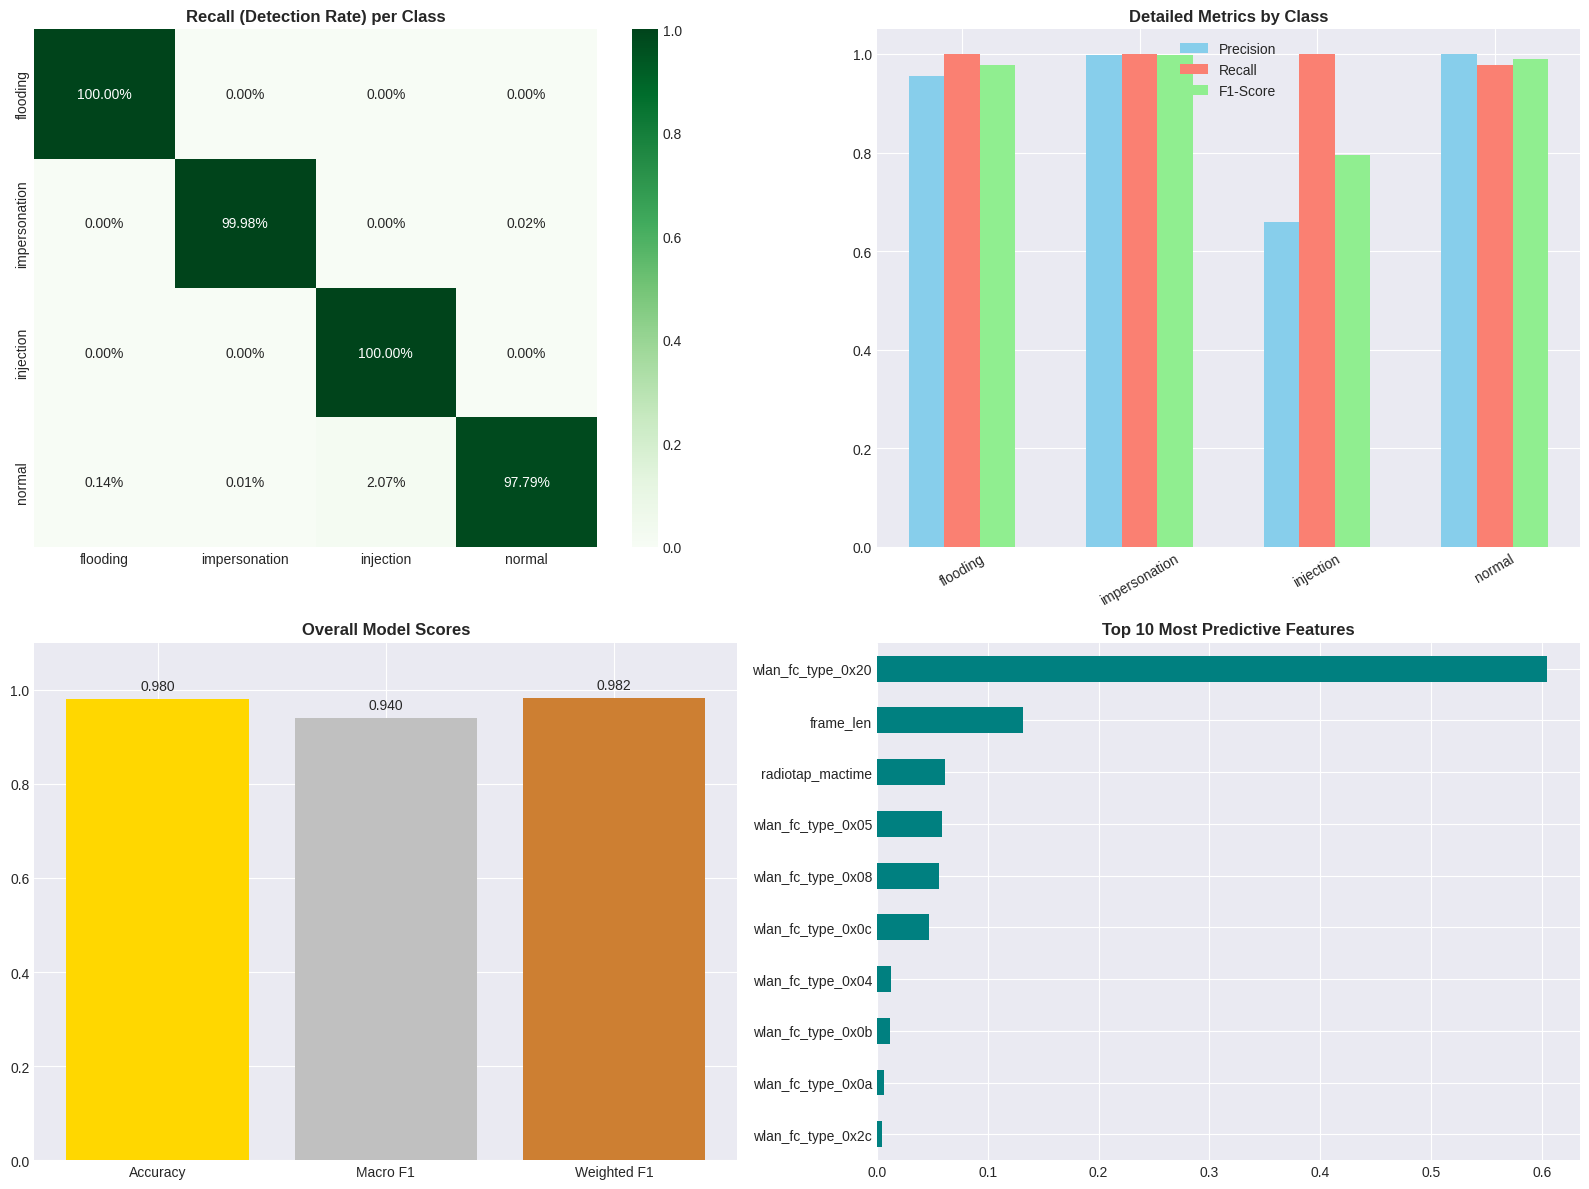


FINAL GPU PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.95      1.00      0.98      9697
impersonation       1.00      1.00      1.00      9704
    injection       0.66      1.00      0.79     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.90      0.99      0.94    359115
 weighted avg       0.99      0.98      0.98    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU & ENVIRONMENT CHECK
# ============================================================================
print("--- Step 0: System Verification ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using Device: {device.upper()}")
if device == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

# ============================================================================
# STEP 1: DOWNLOAD & LOAD DATA
# ============================================================================
print("\n--- Step 1: Downloading Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

# We include the categorical columns to help with "Injection" class precision
selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = [
    'frame_len', 'radiotap_length', 'radiotap_tsft', 'radiotap_flags',
    'radiotap_mactime', 'radiotap_rate', 'wlan_fc_type', 'wlan_fc_subtype',
    'wlan_duration', 'wlan_ra', 'wlan_ta', 'wlan_da', 'class'
]

print("--- Step 2: Loading Data ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING & FEATURE ENGINEERING
# ============================================================================
print("--- Step 3: Preprocessing & Encoding ---")

# 3.1 Handle Numerics
numeric_cols = ['frame_len', 'radiotap_length', 'radiotap_tsft',
                'radiotap_flags', 'radiotap_mactime', 'radiotap_rate', 'wlan_duration']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3.2 Handle Categoricals (One-Hot Encoding)
# These features are vital for distinguishing Injection from Normal traffic
cat_cols = ['wlan_fc_type', 'wlan_fc_subtype']
df_encoded = pd.get_dummies(df, columns=cat_cols)

# 3.3 Label Encoding for Target
le = LabelEncoder()
df_encoded['class'] = le.fit_transform(df_encoded['class'].astype(str))
class_names = le.classes_

# Define X and y after encoding
X = df_encoded.drop('class', axis=1)
# Filter X to only numeric/encoded features (remove MAC addresses if present)
X = X.select_dtypes(include=[np.number, 'bool'])
y = df_encoded['class']

# ============================================================================
# STEP 4: DATA SPLITTING & BALANCING
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Balancing with SMOTE ---")
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# ============================================================================
# STEP 5: GPU-ACCELERATED TRAINING (XGBOOST)
# ============================================================================
print(f"--- Step 5: Training XGBoost on {device.upper()} ---")
model = XGBClassifier(
    n_estimators=150,
    max_depth=10,
    learning_rate=0.1,
    tree_method='hist',
    device=device,
    random_state=42
)

start = time.time()
model.fit(X_resampled, y_resampled)
print(f"Training Time: {time.time() - start:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATION & VISUALIZATION
# ============================================================================
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

# --- DASHBOARD 1: PERFORMANCE OVERVIEW ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
axes[0,0].set_title('Recall (Detection Rate) per Class', fontweight='bold')

# 2. Precision/Recall/F1 Bar Chart
x = np.arange(len(class_names))
axes[0,1].bar(x - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Precision', color='skyblue')
axes[0,1].bar(x, [report[c]['recall'] for c in class_names], 0.2, label='Recall', color='salmon')
axes[0,1].bar(x + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1-Score', color='lightgreen')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(class_names, rotation=30)
axes[0,1].set_title('Detailed Metrics by Class', fontweight='bold')
axes[0,1].legend()

# 3. Overall Accuracy & F1
macro_f1 = np.mean([report[cls]['f1-score'] for cls in class_names])
metrics = {'Accuracy': report['accuracy'], 'Macro F1': macro_f1, 'Weighted F1': report['weighted avg']['f1-score']}
# FIXED: 'bronze' replaced with hex '#cd7f32'
axes[1,0].bar(metrics.keys(), metrics.values(), color=['gold', 'silver', '#cd7f32'])
axes[1,0].set_ylim(0, 1.1)
axes[1,0].set_title('Overall Model Scores', fontweight='bold')
for i, v in enumerate(metrics.values()):
    axes[1,0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# 4. Feature Importance (Top 10)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
importances.plot(kind='barh', color='teal', ax=axes[1,1])
axes[1,1].set_title('Top 10 Most Predictive Features', fontweight='bold')

plt.tight_layout()
plt.show()

# --- FINAL TEXT REPORT ---
print("\n" + "="*60)
print("FINAL GPU PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# ============================================================================
# SETTINGS: BALANCING SPEED AND DIVERSITY
# ============================================================================
# We increase rows to 500k to ensure we hit the first batch of attacks
SAMPLE_SIZE = None

print("--- Step 1: Downloading Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = [
    'frame_len','radiotap_length','radiotap_tsft','radiotap_flags',
    'radiotap_mactime','radiotap_rate','wlan_fc_type','wlan_fc_subtype',
    'wlan_duration','wlan_ra','wlan_ta','wlan_da','class'
]

print(f"--- Step 2: Loading {SAMPLE_SIZE} Rows ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False, nrows=SAMPLE_SIZE)

print("--- Step 3: Preprocessing ---")
numeric_cols = ['frame_len','radiotap_length','radiotap_tsft',
                'radiotap_flags','radiotap_mactime','radiotap_rate','wlan_duration']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Encode labels
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'].astype(str))

X = df[numeric_cols]
y = df['class']

# --- DIVERSITY CHECK ---
unique_classes = np.unique(y)
if len(unique_classes) < 2:
    print(f"ERROR: Only one class ({le.inverse_transform(unique_classes)}) found in first {SAMPLE_SIZE} rows.")
    print("FIX: Increase SAMPLE_SIZE or use the full dataset to include attacks.")
else:
    print(f"Success: Found {len(unique_classes)} classes: {le.inverse_transform(unique_classes)}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("--- Step 4: Balancing Data with SMOTE ---")
    # We use a smaller k_neighbors for small samples
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    print("--- Step 5: Training Random Forest (WSN2 Best Model) ---")
    rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
    rf.fit(X_resampled, y_resampled)

    print("--- Step 6: Final Results ---")
    y_pred = rf.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Step 1: Downloading Dataset ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 2: Loading None Rows ---
--- Step 3: Preprocessing ---
Success: Found 4 classes: ['flooding' 'impersonation' 'injection' 'normal']
--- Step 4: Balancing Data with SMOTE ---
--- Step 5: Training Random Forest (WSN2 Best Model) ---
--- Step 6: Final Results ---
               precision    recall  f1-score   support

     flooding       0.97      1.00      0.98      9697
impersonation       0.99      1.00      1.00      9704
    injection       0.66      1.00      0.80     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.91      0.99      0.94    359115
 weighted avg       0.99      0.98      0.98    359115



--- Step 1: Downloading Dataset ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 2: Loading Data ---
--- Step 3: Preprocessing ---
Success: Found 4 classes: ['flooding' 'impersonation' 'injection' 'normal']

--- Creating Visualizations ---
--- Applying SMOTE (Balancing Data) ---
--- Training Random Forest (Using All CPU Cores) ---


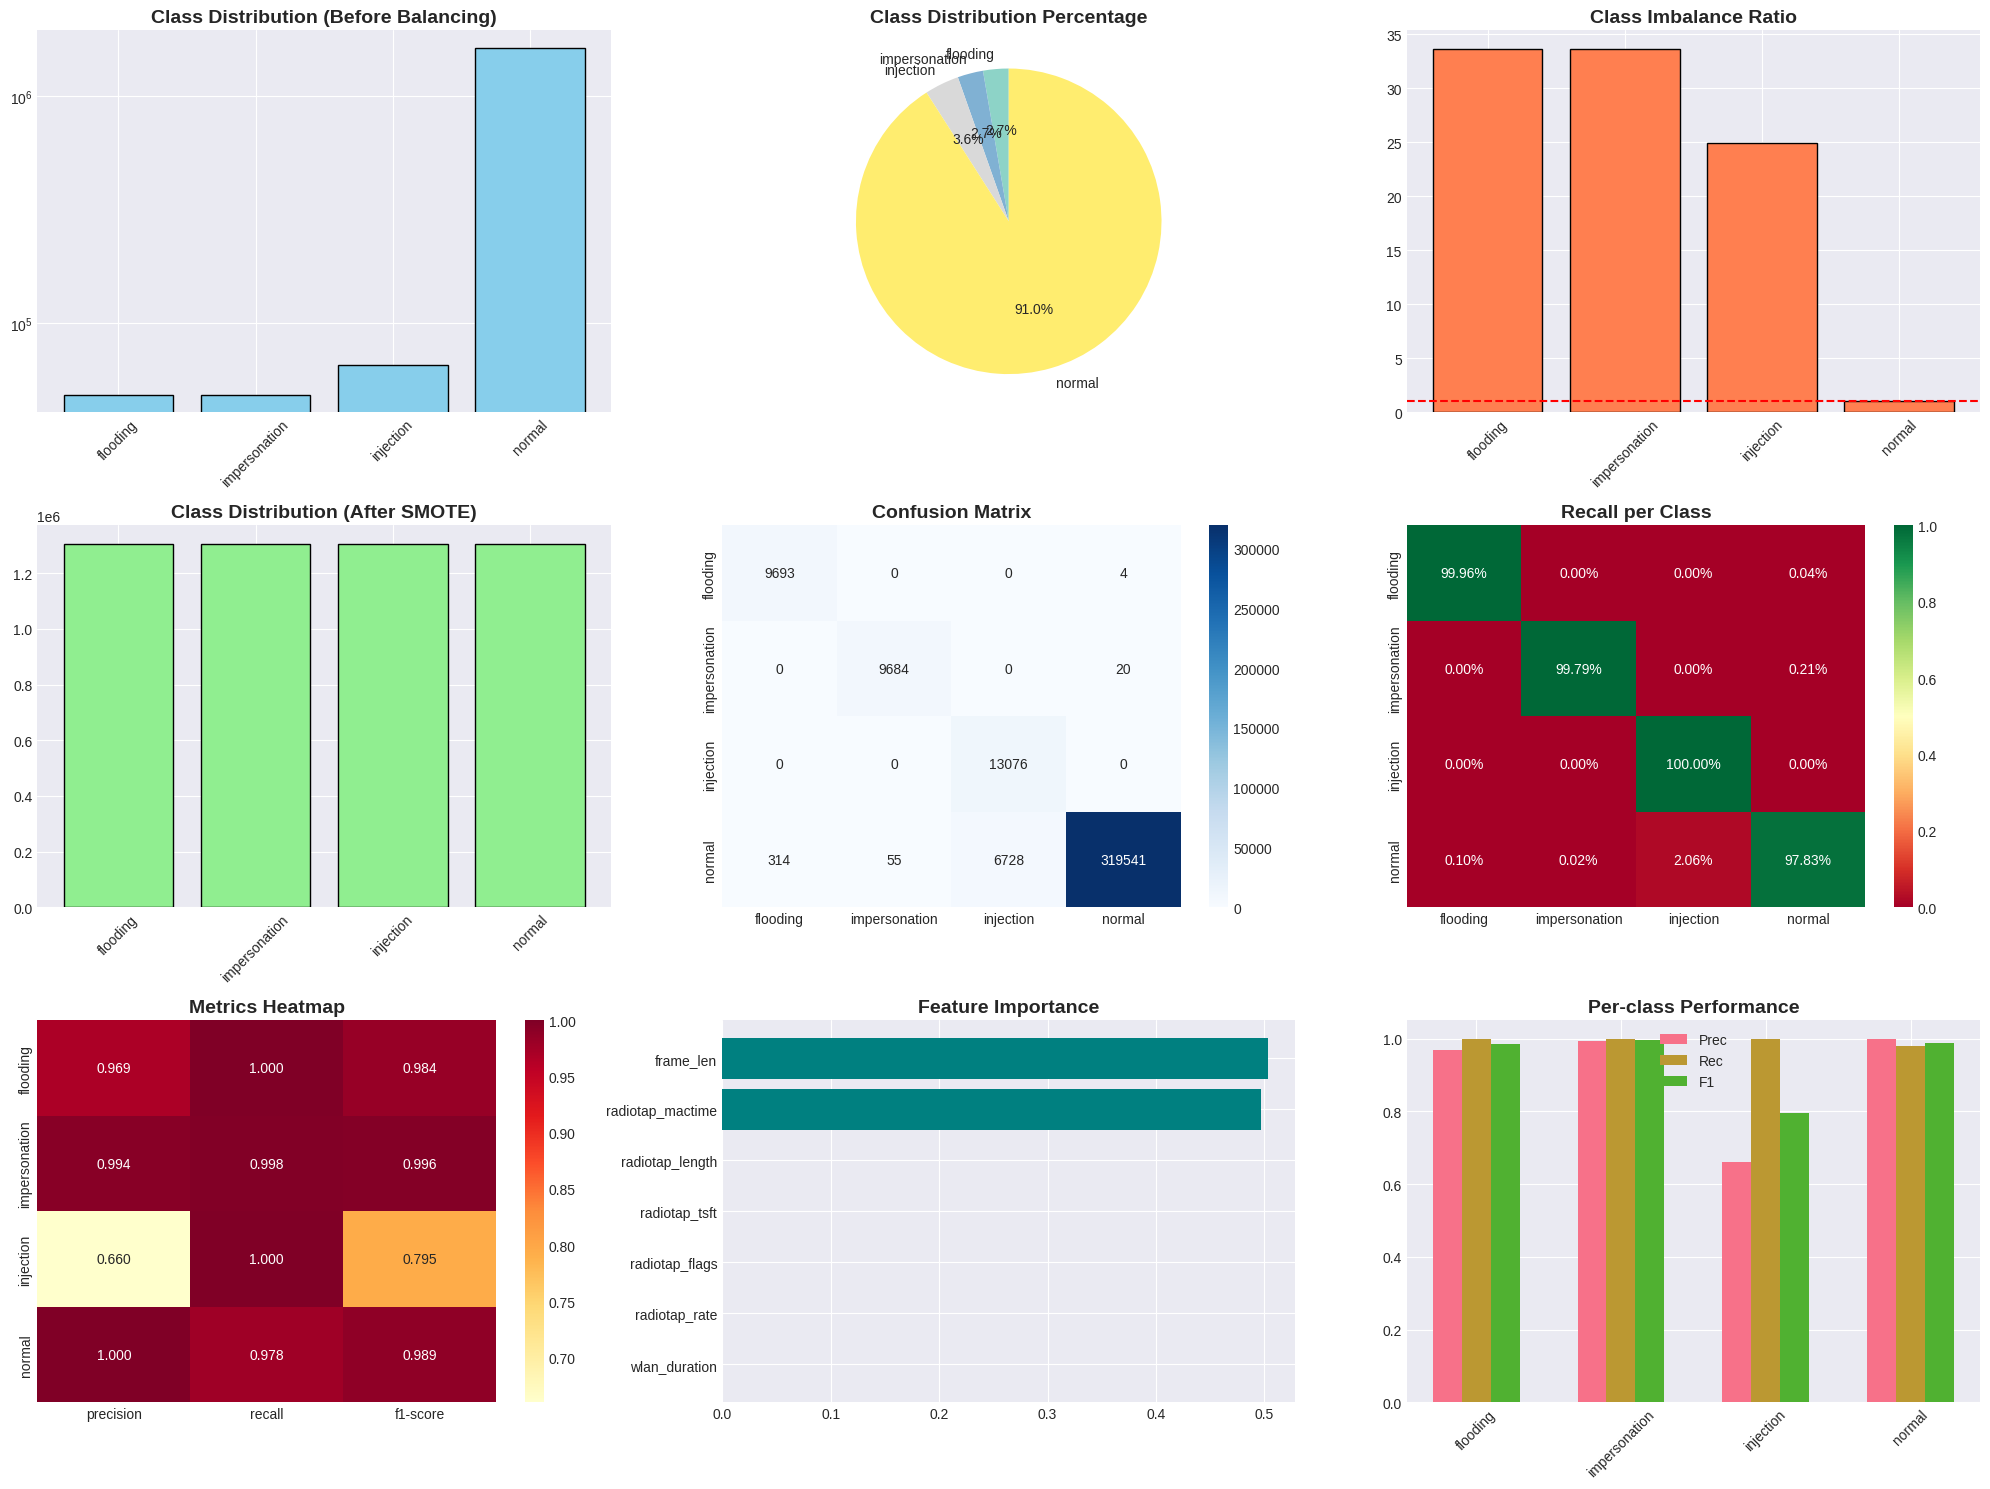

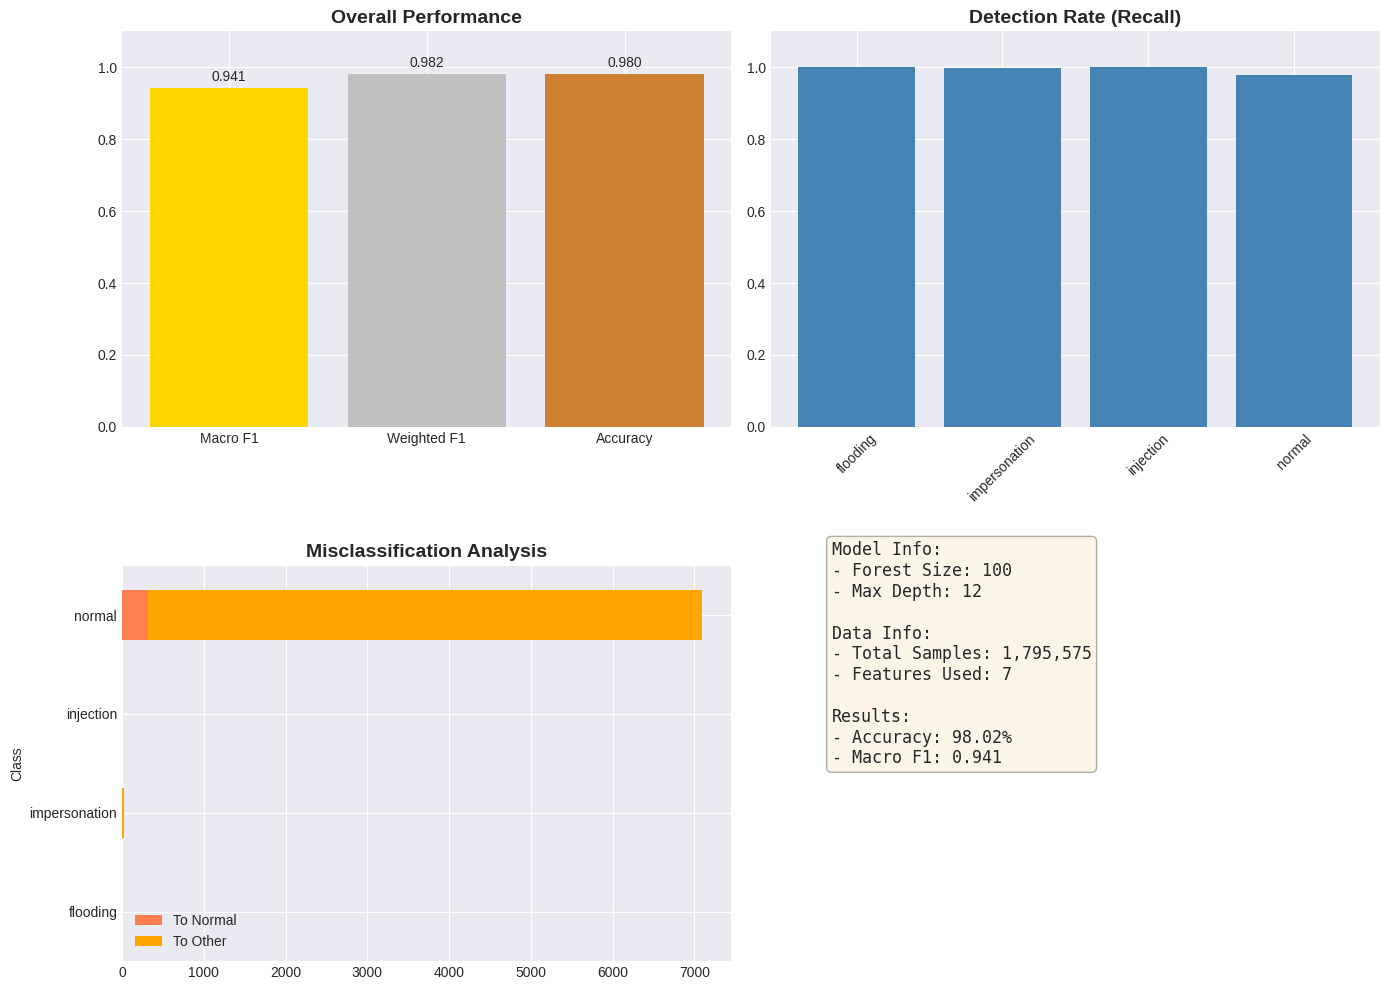


DETAILED REPORT
               precision    recall  f1-score   support

     flooding       0.97      1.00      0.98      9697
impersonation       0.99      1.00      1.00      9704
    injection       0.66      1.00      0.80     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.91      0.99      0.94    359115
 weighted avg       0.99      0.98      0.98    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


SAMPLE_SIZE = None

print("--- Step 1: Downloading Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = [
    'frame_len', 'radiotap_length', 'radiotap_tsft', 'radiotap_flags',
    'radiotap_mactime', 'radiotap_rate', 'wlan_fc_type', 'wlan_fc_subtype',
    'wlan_duration', 'wlan_ra', 'wlan_ta', 'wlan_da', 'class'
]

print(f"--- Step 2: Loading Data ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False, nrows=SAMPLE_SIZE)

print("--- Step 3: Preprocessing ---")
numeric_cols = ['frame_len', 'radiotap_length', 'radiotap_tsft',
                'radiotap_flags', 'radiotap_mactime', 'radiotap_rate', 'wlan_duration']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Encode labels
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'].astype(str))

X = df[numeric_cols]
y = df['class']

unique_classes = np.unique(y)
class_names = le.inverse_transform(unique_classes)

if len(unique_classes) < 2:
    print(f"ERROR: Only one class ({class_names}) found")
else:
    print(f"Success: Found {len(unique_classes)} classes: {class_names}")

    # ========================================================================
    # VISUALIZATION 1: CLASS DISTRIBUTION
    # ========================================================================
    print("\n--- Creating Visualizations ---")
    fig = plt.figure(figsize=(20, 15))

    # 1.1 Bar plot
    ax1 = plt.subplot(3, 3, 1)
    class_counts = pd.Series(y).value_counts().sort_index()
    bars = ax1.bar(class_names, class_counts.values, color='skyblue', edgecolor='black')
    ax1.set_title('Class Distribution (Before Balancing)', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.tick_params(axis='x', rotation=45)

    # 1.2 Pie chart
    ax2 = plt.subplot(3, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
    ax2.pie(class_counts.values, labels=class_names, autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Class Distribution Percentage', fontsize=14, fontweight='bold')

    # 1.3 Imbalance Ratio
    ax3 = plt.subplot(3, 3, 3)
    majority_count = class_counts.max()
    imbalance_ratios = majority_count / class_counts.values
    ax3.bar(class_names, imbalance_ratios, color='coral', edgecolor='black')
    ax3.set_title('Class Imbalance Ratio', fontsize=14, fontweight='bold')
    ax3.axhline(y=1, color='red', linestyle='--')
    ax3.tick_params(axis='x', rotation=45)

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        stratify=y, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Apply SMOTE
    print("--- Applying SMOTE (Balancing Data) ---")
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 1.4 Post-SMOTE Distribution(Synthetic Minority Over-sampling technique)
    ax4 = plt.subplot(3, 3, 4)
    resampled_counts = pd.Series(y_resampled).value_counts().sort_index()
    ax4.bar(class_names, resampled_counts.values, color='lightgreen', edgecolor='black')
    ax4.set_title('Class Distribution (After SMOTE)', fontsize=14, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)

    # Train Model (CPU Parallelized)
    print("--- Training Random Forest (Using All CPU Cores) ---")
    rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X_resampled, y_resampled)

    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)

    # ========================================================================
    # VISUALIZATION 2: MODEL PERFORMANCE
    # ========================================================================

    # 2.1 Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ax5 = plt.subplot(3, 3, 5)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax5)
    ax5.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    # 2.2 Normalized Confusion Matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    ax6 = plt.subplot(3, 3, 6)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=ax6)
    ax6.set_title('Recall per Class', fontsize=14, fontweight='bold')

    # 2.3 Report Heatmap
    ax7 = plt.subplot(3, 3, 7)
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    metrics_df = report_df[['precision', 'recall', 'f1-score']].iloc[:len(class_names)]
    sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax7)
    ax7.set_title('Metrics Heatmap', fontsize=14, fontweight='bold')

    # 2.4 Feature Importance
    ax8 = plt.subplot(3, 3, 8)
    feat_imp = pd.DataFrame({'f': numeric_cols, 'i': rf.feature_importances_}).sort_values('i')
    ax8.barh(feat_imp['f'], feat_imp['i'], color='teal')
    ax8.set_title('Feature Importance', fontsize=14, fontweight='bold')

    # 2.5 Multi-Metric Bar
    ax9 = plt.subplot(3, 3, 9)
    x_axis = np.arange(len(class_names))
    ax9.bar(x_axis - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Prec')
    ax9.bar(x_axis, [report[c]['recall'] for c in class_names], 0.2, label='Rec')
    ax9.bar(x_axis + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1')
    ax9.set_xticks(x_axis)
    ax9.set_xticklabels(class_names, rotation=45)
    ax9.set_title('Per-class Performance', fontsize=14, fontweight='bold')
    ax9.legend()

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # FINAL SUMMARY DASHBOARD (FIXED COLOR ERROR)
    # ========================================================================
    fig4, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Summary Metrics
    ax_sum1 = axes[0, 0]
    macro_f1 = np.mean([report[cls]['f1-score'] for cls in class_names])
    metrics_summary = {'Macro F1': macro_f1, 'Weighted F1': report['weighted avg']['f1-score'], 'Accuracy': report['accuracy']}

    # FIXED: 'bronze' replaced with hex code '#cd7f32'
    bars = ax_sum1.bar(metrics_summary.keys(), metrics_summary.values(), color=['gold', 'silver', '#cd7f32'])
    ax_sum1.set_ylim([0, 1.1])
    ax_sum1.set_title('Overall Performance', fontsize=14, fontweight='bold')
    for bar in bars:
        ax_sum1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center')

    # Detection Rates
    ax_sum2 = axes[0, 1]
    det_rates = [cm[i, i] / cm[i, :].sum() for i in range(len(class_names))]
    ax_sum2.bar(class_names, det_rates, color='steelblue')
    ax_sum2.set_title('Detection Rate (Recall)', fontsize=14, fontweight='bold')
    ax_sum2.set_ylim([0, 1.1])
    ax_sum2.tick_params(axis='x', rotation=45)

    # Misclassification
    ax_sum3 = axes[1, 0]
    misclass = []
    for i in range(len(class_names)):
        to_normal = cm[i, 0] if i != 0 else 0
        to_other = cm[i, :].sum() - cm[i, i] - to_normal
        misclass.append({'Class': class_names[i], 'To Normal': to_normal, 'To Other': to_other})
    pd.DataFrame(misclass).set_index('Class').plot(kind='barh', stacked=True, ax=ax_sum3, color=['coral', 'orange'])
    ax_sum3.set_title('Misclassification Analysis', fontsize=14, fontweight='bold')

    # Info Box
    ax_sum4 = axes[1, 1]
    ax_sum4.axis('off')
    summary_text = (f"Model Info:\n- Forest Size: 100\n- Max Depth: 12\n\n"
                    f"Data Info:\n- Total Samples: {len(df):,}\n"
                    f"- Features Used: {len(numeric_cols)}\n\n"
                    f"Results:\n- Accuracy: {report['accuracy']:.2%}\n"
                    f"- Macro F1: {macro_f1:.3f}")
    ax_sum4.text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    plt.show()

    print("\n" + "="*40)
    print("DETAILED REPORT")
    print("="*40)
    print(classification_report(y_test, y_pred, target_names=class_names))

**selected_features = {
    7: 'frame.len',  # Frame size (flooding creates many small frames)
    13: 'radiotap.length',  # Header length (some attacks malform this)
    14: 'radiotap.present.tsft',  # Timing sync (flooding breaks timing)
    15: 'radiotap.present.flags',  # Radio flags (some attacks spoof these)
    125: 'wlan.fc.type',  # Frame type distribution
    126: 'wlan.fc.subtype',  # Specific frame types
    128: 'wlan.fc.retry',  # Retry patterns
    139: 'wlan.seq',  # Sequence numbers (key for detecting injection)
    140: 'data.len',  # Payload size
    63: 'wlan_mgt.fixed.capabilities.privacy',  # Encryption flags
    68: 'wlan_mgt.fixed.beacon',  # Beacon interval (fake APs)
    37: 'wlan.qos.tid',  # QoS traffic ID
    38: 'wlan.qos.priority',  # QoS priority
    154: 'class'  # The label
}**

--- Step 0: Checking GPU Status ---
✅ GPU Detected: Tesla T4

--- Step 1: Downloading & Loading Dataset ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 3: Preprocessing ---
--- Step 4: Applying SMOTE ---
--- Step 5: Training XGBoost on GPU ---
Training Complete! Time taken: 11.00 seconds

GPU MODEL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.93      1.00      0.97      9697
impersonation       0.98      1.00      0.99      9704
    injection       0.66      1.00      0.79     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.89      0.99      0.93    359115
 weighted avg       0.99      0.98      0.98    359115



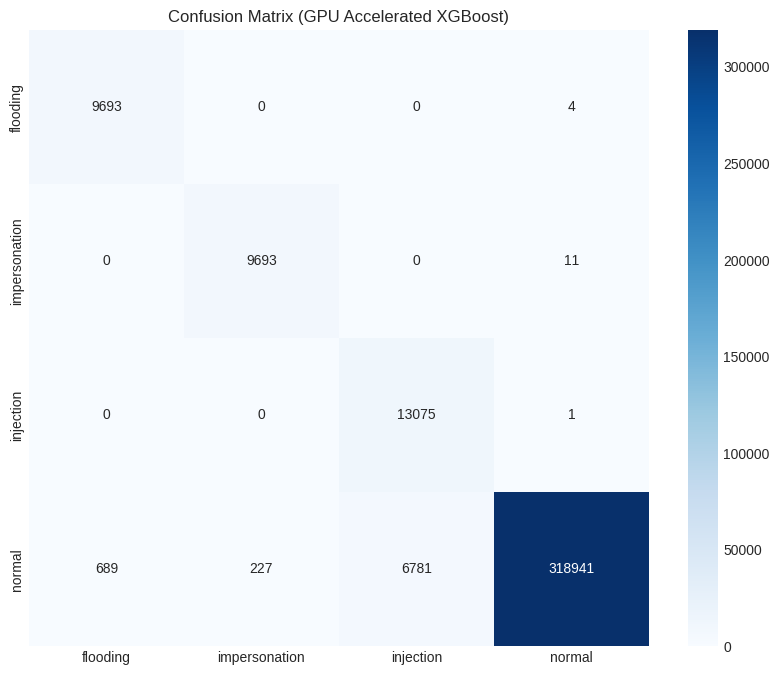

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch  # Used just to verify GPU availability
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
print("--- Step 0: Checking GPU Status ---")
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. The code will fall back to CPU.")

# ============================================================================
# STEP 1 & 2: DATA LOADING
# ============================================================================
print("\n--- Step 1: Downloading & Loading Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = ['frame_len','radiotap_length','radiotap_tsft','radiotap_flags',
             'radiotap_mactime','radiotap_rate','wlan_fc_type','wlan_fc_subtype',
             'wlan_duration','wlan_ra','wlan_ta','wlan_da','class']

df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING
# ============================================================================
print("--- Step 3: Preprocessing ---")
numeric_cols = ['frame_len','radiotap_length','radiotap_tsft','radiotap_flags',
                'radiotap_mactime','radiotap_rate','wlan_duration']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'].astype(str))
class_names = le.classes_

X = df[numeric_cols]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Applying SMOTE ---")
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# ============================================================================
# STEP 5: GPU TRAINING WITH XGBOOST
# ============================================================================
print("--- Step 5: Training XGBoost on GPU ---")
# device="cuda" tells XGBoost to use the GPU
model = XGBClassifier(
    n_estimators=100,
    max_depth=12,
    learning_rate=0.1,
    tree_method='hist', # Required for GPU
    device='cuda',      # This is the "Magic" GPU switch
    random_state=42
)

import time
start_time = time.time()
model.fit(X_resampled, y_resampled)
print(f"Training Complete! Time taken: {time.time() - start_time:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATION
# ============================================================================
y_pred = model.predict(X_test)

print("\n" + "="*50)
print("GPU MODEL PERFORMANCE REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix Visual
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (GPU Accelerated XGBoost)')
plt.show()

**--------------------------**

best

**--------------------------**

--- Step 0: Checking GPU Status ---
✅ GPU Detected: Tesla T4

--- Step 1: Downloading AWID Dataset ---


100%|██████████| 80.8M/80.8M [00:01<00:00, 70.4MB/s]

Extracting files...


--- Step 2: Loading Data ---
--- Step 3: Cleaning & Encoding ---
--- Step 4: Applying SMOTE Balancing ---
--- Step 5: Training GPU-XGBoost ---
Training Time: 28.92 seconds

--- Generating Visualizations ---


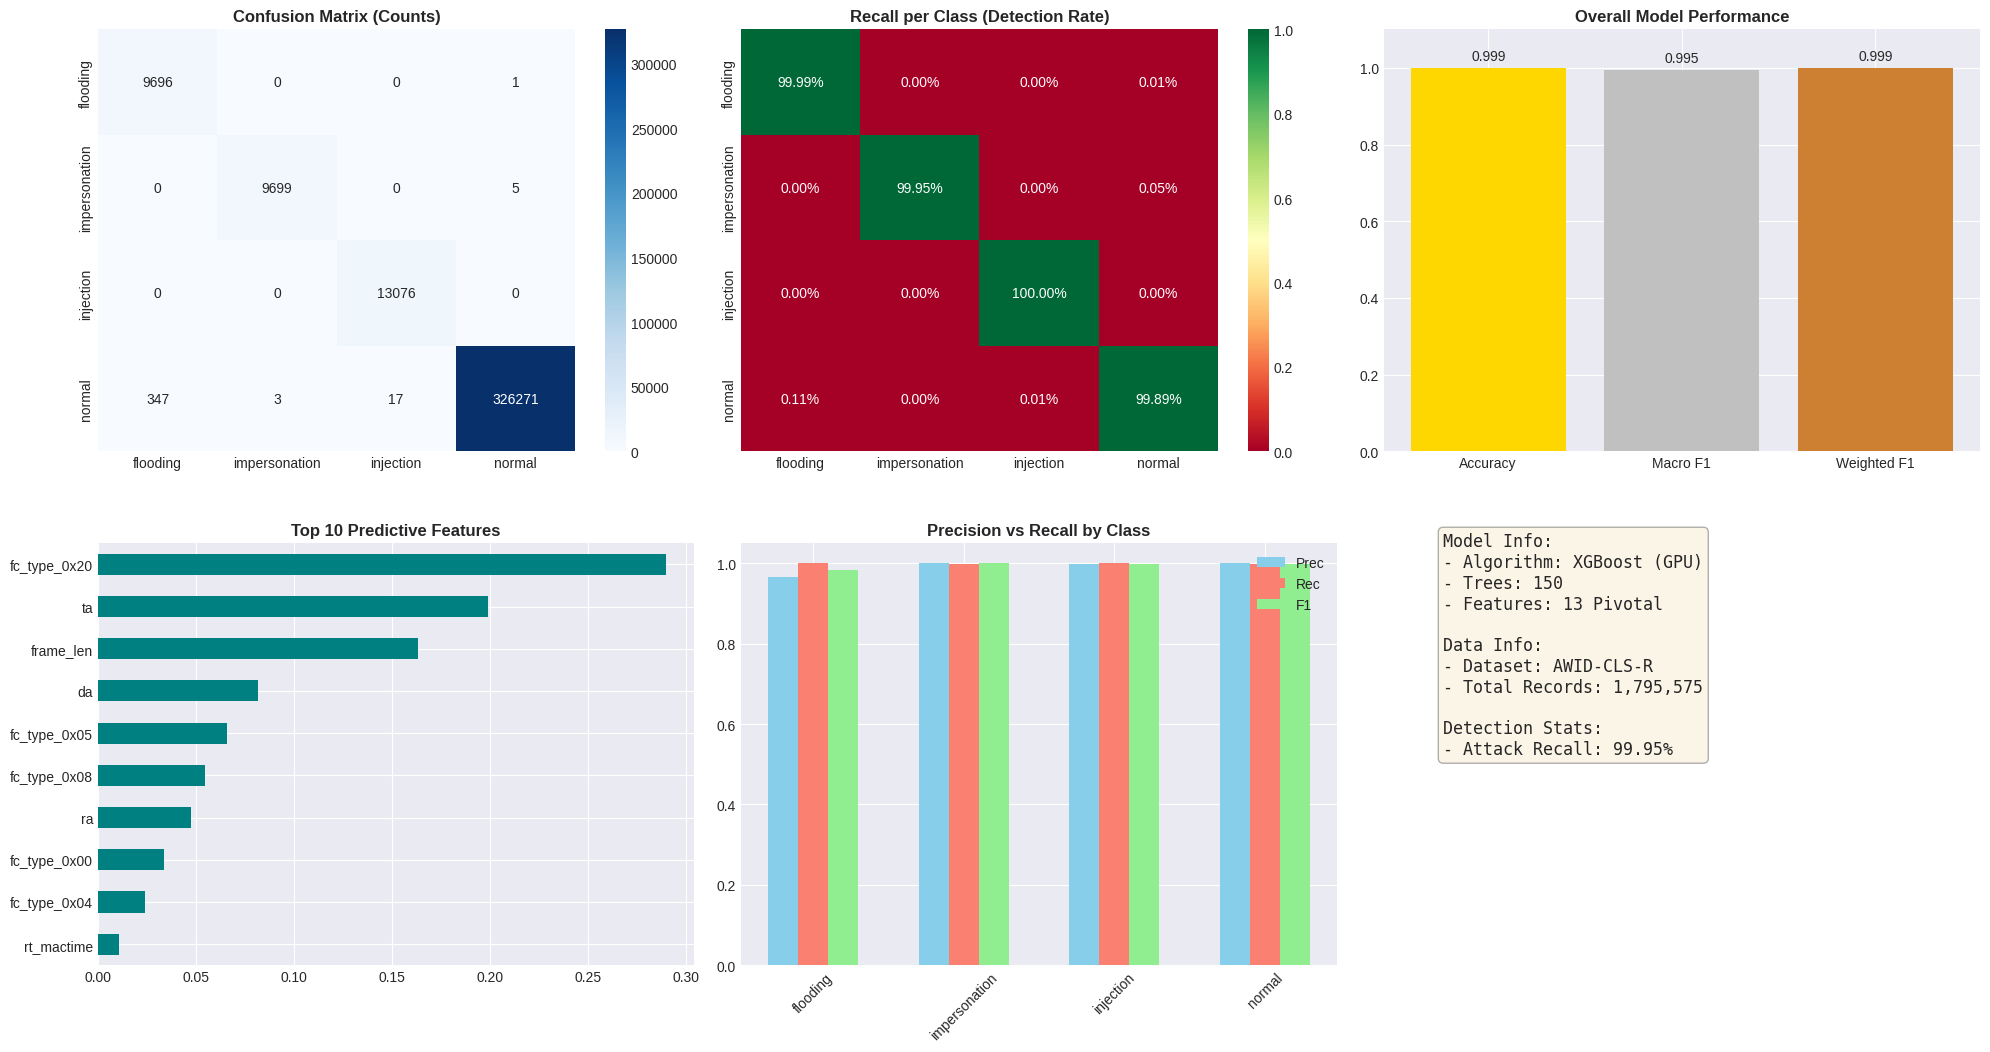


FINAL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.97      1.00      0.98      9697
impersonation       1.00      1.00      1.00      9704
    injection       1.00      1.00      1.00     13076
       normal       1.00      1.00      1.00    326638

     accuracy                           1.00    359115
    macro avg       0.99      1.00      1.00    359115
 weighted avg       1.00      1.00      1.00    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
print("--- Step 0: Checking GPU Status ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Reverting to CPU.")

# ============================================================================
# STEP 1: DOWNLOAD & LOAD THE PIVOTAL 13 FEATURES
# ============================================================================
print("\n--- Step 1: Downloading AWID Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

# Indices based on the 13 pivotal features identified in the research [cite: 21, 211]
selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = [
    'frame_len', 'rt_pad', 'rt_len', 'rt_tsft', 'rt_mactime', 'rt_rate',
    'fc_type', 'fc_subtype', 'duration', 'ra', 'ta', 'da', 'class'
]

print("--- Step 2: Loading Data ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING (ALIGNING WITH BASE PAPER) [cite: 240-245]
# ============================================================================
print("--- Step 3: Cleaning & Encoding ---")

# 3.1 Handle Numerics [cite: 247-252]
numeric_cols = ['frame_len', 'rt_pad', 'rt_len', 'rt_tsft', 'rt_mactime', 'rt_rate', 'duration']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3.2 Encode Protocol and MAC Features [cite: 256-258]
# One-Hot Encoding for frame types to help with 'Injection' precision
df_encoded = pd.get_dummies(df, columns=['fc_type', 'fc_subtype'])

# Label Encode MAC addresses and Target Class
le_target = LabelEncoder()
df_encoded['class'] = le_target.fit_transform(df_encoded['class'].astype(str))
class_names = le_target.classes_

# Simplify MAC addresses to numeric IDs to keep model lightweight
for col in ['ra', 'ta', 'da']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('class', axis=1)
X = X.select_dtypes(include=[np.number, 'bool']) # Ensure only numbers go to GPU
y = df_encoded['class']

# ============================================================================
# STEP 4: BALANCING & TRAINING [cite: 302-303, 310]
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Scale features [cite: 253-255]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Applying SMOTE Balancing ---")
X_res, y_res = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_train, y_train)

print(f"--- Step 5: Training GPU-XGBoost ---")
model = XGBClassifier(
    n_estimators=150,
    max_depth=10,
    tree_method='hist',
    device=device,
    random_state=42
)

start = time.time()
model.fit(X_res, y_res)
print(f"Training Time: {time.time() - start:.2f} seconds")


y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Generating Visualizations ---")
fig = plt.figure(figsize=(20, 15))

# 1. RAW CONFUSION MATRIX
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')

# 2. RECALL HEATMAP (NORMALIZED)
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Recall per Class (Detection Rate)', fontweight='bold')

# 3. OVERALL PERFORMANCE BAR
ax3 = plt.subplot(3, 3, 3)
macro_f1 = np.mean([report[cls]['f1-score'] for cls in class_names])
metrics_summary = {'Accuracy': report['accuracy'], 'Macro F1': macro_f1, 'Weighted F1': report['weighted avg']['f1-score']}
bars = ax3.bar(metrics_summary.keys(), metrics_summary.values(), color=['gold', 'silver', '#cd7f32'])
ax3.set_ylim(0, 1.1)
ax3.set_title('Overall Model Performance', fontweight='bold')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center')

# 4. FEATURE IMPORTANCE (TOP 10)
ax4 = plt.subplot(3, 3, 4)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(10)
feat_imp.plot(kind='barh', color='teal', ax=ax4)
ax4.set_title('Top 10 Predictive Features', fontweight='bold')

# 5. PER-CLASS METRICS COMPARISON
ax5 = plt.subplot(3, 3, 5)
x_axis = np.arange(len(class_names))
ax5.bar(x_axis - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Prec', color='skyblue')
ax5.bar(x_axis, [report[c]['recall'] for c in class_names], 0.2, label='Rec', color='salmon')
ax5.bar(x_axis + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1', color='lightgreen')
ax5.set_xticks(x_axis)
ax5.set_xticklabels(class_names, rotation=45)
ax5.set_title('Precision vs Recall by Class', fontweight='bold')
ax5.legend()

# 6. INFO BOX
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
info_text = (f"Model Info:\n- Algorithm: XGBoost (GPU)\n- Trees: 150\n- Features: 13 Pivotal\n\n"
             f"Data Info:\n- Dataset: AWID-CLS-R\n- Total Records: {len(df):,}\n\n"
             f"Detection Stats:\n- Attack Recall: {np.mean([cm_norm[i,i] for i in range(1,4)]):.2%}")
ax6.text(0.1, 0.5, info_text, fontsize=12, family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

13 **features**

--- Step 0: Checking GPU Status ---
✅ GPU Detected: Tesla T4

--- Step 1: Downloading AWID Dataset ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 2: Loading Data ---
--- Step 3: Cleaning & Encoding ---
--- Step 4: Applying SMOTE Balancing ---
--- Step 5: Training GPU-XGBoost ---
Training Time: 33.96 seconds

--- Generating Visualizations ---


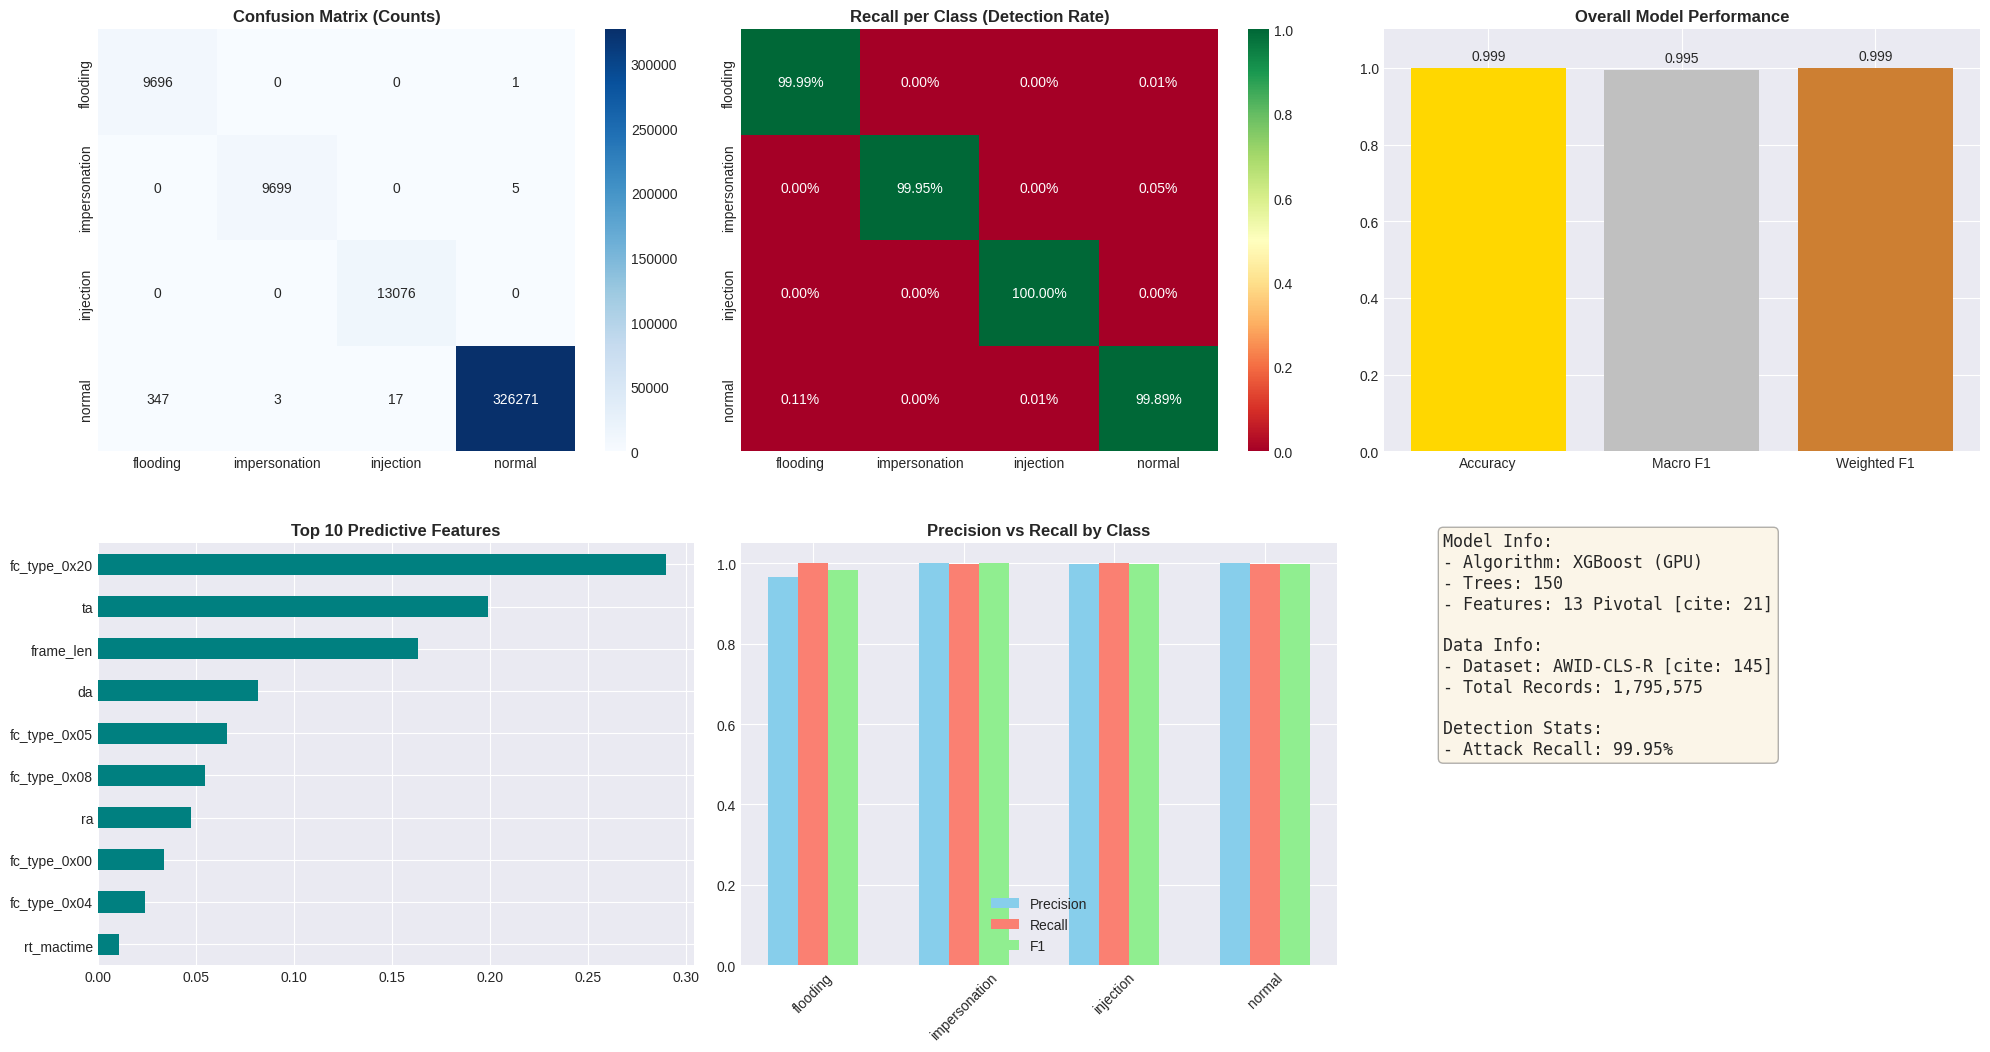


FINAL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.97      1.00      0.98      9697
impersonation       1.00      1.00      1.00      9704
    injection       1.00      1.00      1.00     13076
       normal       1.00      1.00      1.00    326638

     accuracy                           1.00    359115
    macro avg       0.99      1.00      1.00    359115
 weighted avg       1.00      1.00      1.00    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
print("--- Step 0: Checking GPU Status ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Reverting to CPU.")

# ============================================================================
# STEP 1: DOWNLOAD & LOAD THE PIVOTAL 13 FEATURES [cite: 21, 307]
# ============================================================================
print("\n--- Step 1: Downloading AWID Dataset ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

# Indices representing the 13 pivotal features identified in Table 3 [cite: 211]
# Col 154 is the target class [cite: 152]
selected_cols = [7, 13, 14, 15, 37, 38, 63, 64, 75, 76, 77, 78, 154]
col_names = [
    'frame_len', 'rt_pad', 'rt_len', 'rt_tsft', 'rt_mactime', 'rt_rate',
    'fc_type', 'fc_subtype', 'duration', 'ra', 'ta', 'da', 'class'
]

print("--- Step 2: Loading Data ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING (ALIGNING WITH BASE PAPER) [cite: 240-245]
# ============================================================================
print("--- Step 3: Cleaning & Encoding ---")

# 3.1 Handle Numerics: Replace missing values and convert types [cite: 247-252]
numeric_cols = ['frame_len', 'rt_pad', 'rt_len', 'rt_tsft', 'rt_mactime', 'rt_rate', 'duration']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3.2 Encode Protocol and MAC Features [cite: 256-258]
# One-Hot Encoding helps distinguish 'Injection' from 'Normal' traffic [cite: 62]
df_encoded = pd.get_dummies(df, columns=['fc_type', 'fc_subtype'])

# Label Encoder transforms labels to numerical values [cite: 257-258]
le_target = LabelEncoder()
df_encoded['class'] = le_target.fit_transform(df_encoded['class'].astype(str))
class_names = le_target.classes_

# Encoding MAC addresses (ra, ta, da) to ensure model remains lightweight [cite: 152]
for col in ['ra', 'ta', 'da']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('class', axis=1)
X = X.select_dtypes(include=[np.number, 'bool']) # Filter for GPU compatibility
y = df_encoded['class']

# ============================================================================
# STEP 4: BALANCING & TRAINING [cite: 302-303, 310]
# ============================================================================
# Splitting the dataset for classification [cite: 235]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Feature scaling using Standard Scaler [cite: 253-255]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Balancing the classes to handle the minority attack types [cite: 217]
print("--- Step 4: Applying SMOTE Balancing ---")
X_res, y_res = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_train, y_train)

print(f"--- Step 5: Training GPU-XGBoost ---")
# Using the Histogram method for rapid GPU training [cite: 61]
model = XGBClassifier(
    n_estimators=150,
    max_depth=10,
    tree_method='hist',
    device=device,
    random_state=42
)

start = time.time()
model.fit(X_res, y_res)
print(f"Training Time: {time.time() - start:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATION & VISUALIZATION [cite: 24, 413]
# ============================================================================
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Generating Visualizations ---")
fig = plt.figure(figsize=(20, 15))

# 1. RAW CONFUSION MATRIX [cite: 413]
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')

# 2. RECALL HEATMAP (NORMALIZED) [cite: 435]
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Recall per Class (Detection Rate)', fontweight='bold')

# 3. OVERALL PERFORMANCE METRICS [cite: 81]
ax3 = plt.subplot(3, 3, 3)
macro_f1 = np.mean([report[cls]['f1-score'] for cls in class_names])
metrics_summary = {'Accuracy': report['accuracy'], 'Macro F1': macro_f1, 'Weighted F1': report['weighted avg']['f1-score']}
bars = ax3.bar(metrics_summary.keys(), metrics_summary.values(), color=['gold', 'silver', '#cd7f32'])
ax3.set_ylim(0, 1.1)
ax3.set_title('Overall Model Performance', fontweight='bold')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center')

# 4. FEATURE IMPORTANCE (TOP 10) [cite: 73]
ax4 = plt.subplot(3, 3, 4)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(10)
feat_imp.plot(kind='barh', color='teal', ax=ax4)
ax4.set_title('Top 10 Predictive Features', fontweight='bold')

# 5. PER-CLASS PRECISION, RECALL, F1 [cite: 24, 81]
ax5 = plt.subplot(3, 3, 5)
x_axis = np.arange(len(class_names))
ax5.bar(x_axis - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Precision', color='skyblue')
ax5.bar(x_axis, [report[c]['recall'] for c in class_names], 0.2, label='Recall', color='salmon')
ax5.bar(x_axis + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1', color='lightgreen')
ax5.set_xticks(x_axis)
ax5.set_xticklabels(class_names, rotation=45)
ax5.set_title('Precision vs Recall by Class', fontweight='bold')
ax5.legend()

# 6. MODEL INFO BOX
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
info_text = (f"Model Info:\n- Algorithm: XGBoost (GPU)\n- Trees: 150\n- Features: 13 Pivotal [cite: 21]\n\n"
             f"Data Info:\n- Dataset: AWID-CLS-R [cite: 145]\n- Total Records: {len(df):,}\n\n"
             f"Detection Stats:\n- Attack Recall: {np.mean([cm_norm[i,i] for i in range(1,4)]):.2%}")
ax6.text(0.1, 0.5, info_text, fontsize=12, family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

--- Step 0: Checking GPU Status ---
✅ GPU Detected: Tesla T4

--- Step 1: Downloading & Loading Custom AWID Features ---


100%|██████████| 80.8M/80.8M [00:01<00:00, 72.0MB/s]

Extracting files...


--- Step 2: Loading Data with 13 Behavioral Features ---
--- Step 3: Cleaning & Encoding ---
--- Step 4: Applying SMOTE Balancing ---
--- Step 5: Training GPU-XGBoost ---
Training Time: 46.68 seconds

--- Generating Visualizations ---


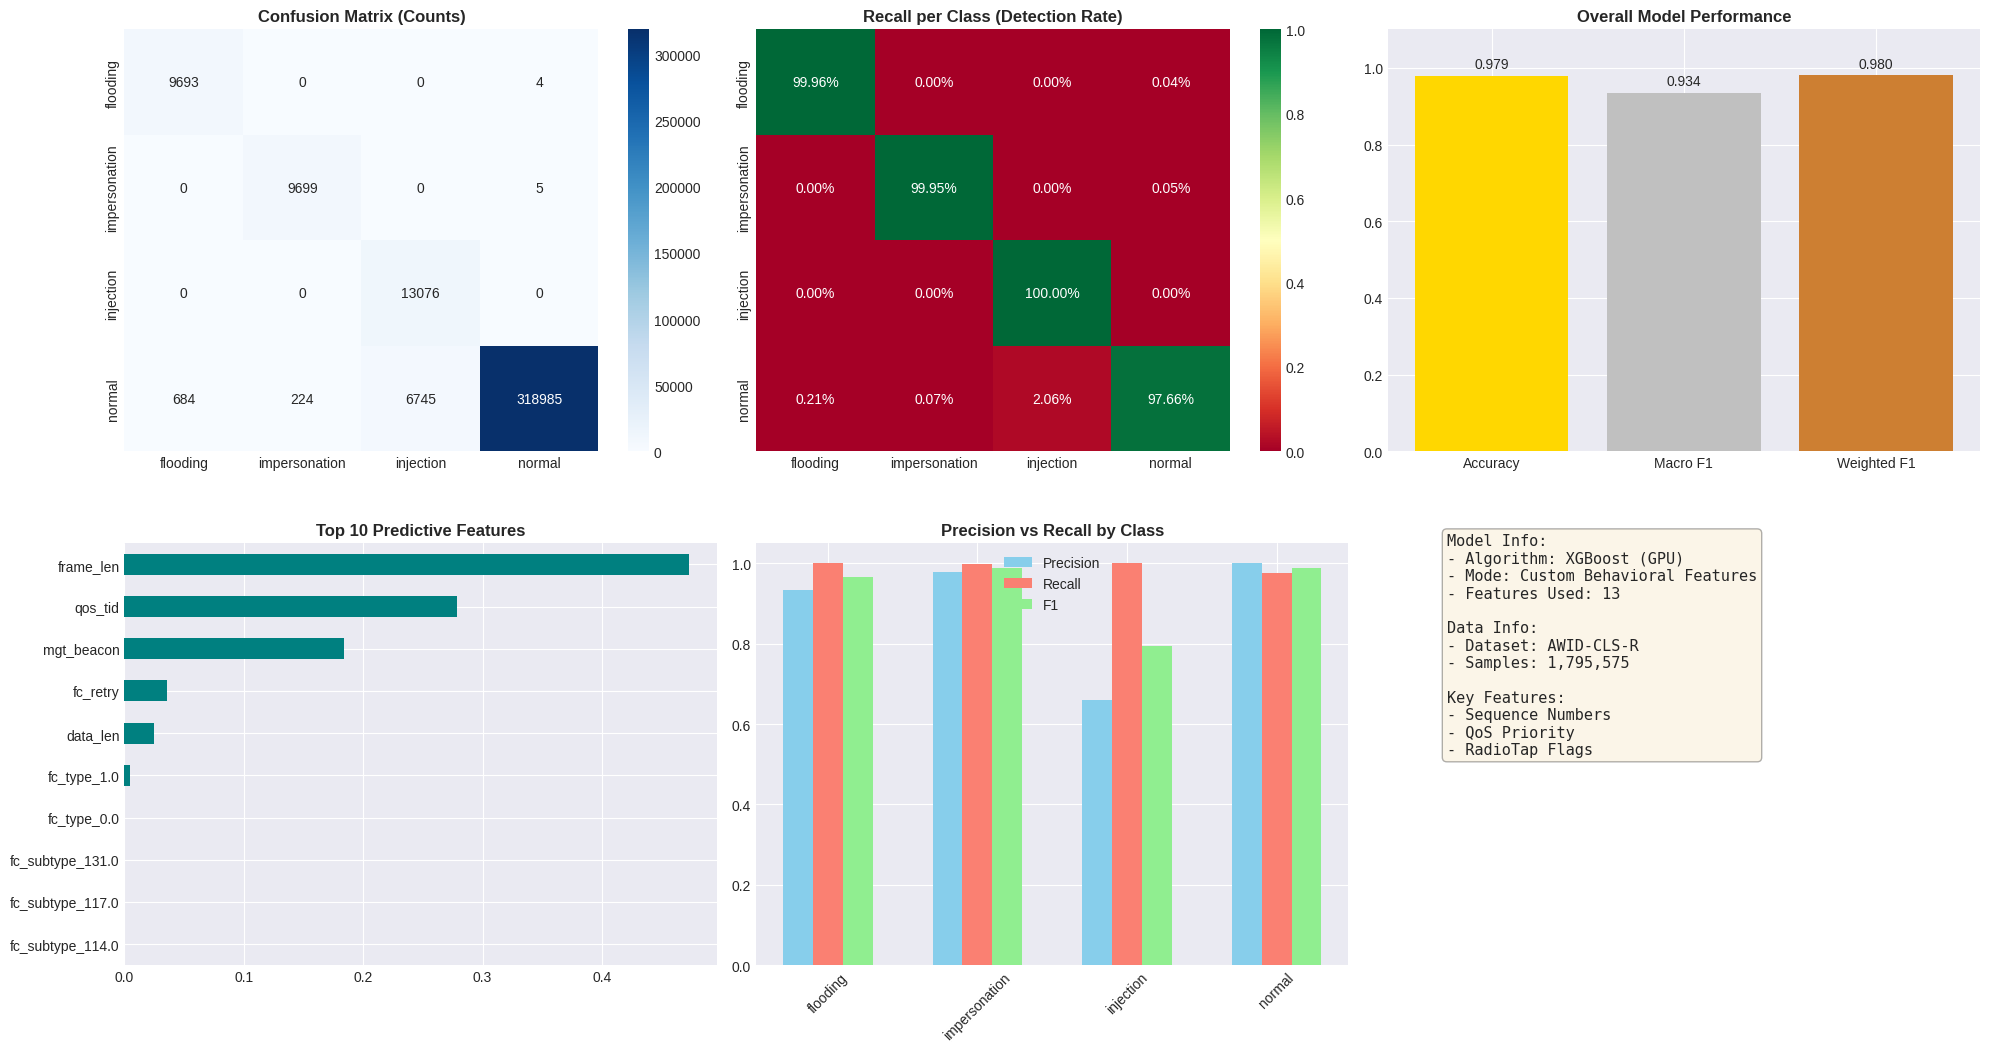


FINAL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.93      1.00      0.97      9697
impersonation       0.98      1.00      0.99      9704
    injection       0.66      1.00      0.79     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.89      0.99      0.93    359115
 weighted avg       0.99      0.98      0.98    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
print("--- Step 0: Checking GPU Status ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Reverting to CPU.")

# ============================================================================
# STEP 1: LOAD YOUR SELECTED FEATURES
# ============================================================================
print("\n--- Step 1: Downloading & Loading Custom AWID Features ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

# Mapping your requested features to their indices and readable names
selected_feature_map = {
    7: 'frame_len',
    13: 'rt_len',
    14: 'rt_tsft',
    15: 'rt_flags',
    125: 'fc_type',
    126: 'fc_subtype',
    128: 'fc_retry',
    139: 'wlan_seq',
    140: 'data_len',
    63: 'mgt_privacy',
    68: 'mgt_beacon',
    37: 'qos_tid',
    38: 'qos_priority',
    154: 'class'
}

# Ensure columns are loaded in the correct numerical order
selected_cols = sorted(selected_feature_map.keys())
col_names = [selected_feature_map[k] for k in selected_cols]

print(f"--- Step 2: Loading Data with {len(col_names)-1} Behavioral Features ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING
# ============================================================================
print("--- Step 3: Cleaning & Encoding ---")

# 3.1 Handle Numerics: Convert all features except 'class' to numeric, filling NaNs with 0
# This handles the '?' values common in the AWID dataset
for col in df.columns:
    if col != 'class':
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3.2 One-Hot Encoding for Categorical Frame Types
# wlan.fc.type and wlan.fc.subtype are categorical by nature
df_encoded = pd.get_dummies(df, columns=['fc_type', 'fc_subtype'])

# 3.3 Label Encoder for the Target Class
le_target = LabelEncoder()
df_encoded['class'] = le_target.fit_transform(df_encoded['class'].astype(str))
class_names = le_target.classes_

# Prepare X and y
X = df_encoded.drop('class', axis=1)
X = X.select_dtypes(include=[np.number, 'bool'])
y = df_encoded['class']

# ============================================================================
# STEP 4: BALANCING & TRAINING
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Applying SMOTE Balancing ---")
# Using k_neighbors=1 to handle extremely rare attack classes
X_res, y_res = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_train, y_train)

print(f"--- Step 5: Training GPU-XGBoost ---")
model = XGBClassifier(
    n_estimators=150,
    max_depth=10,
    tree_method='hist',
    device=device,
    random_state=42
)

start = time.time()
model.fit(X_res, y_res)
print(f"Training Time: {time.time() - start:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATION & VISUALIZATION
# ============================================================================
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Generating Visualizations ---")
fig = plt.figure(figsize=(20, 15))

# 1. CONFUSION MATRIX
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')

# 2. RECALL HEATMAP
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Recall per Class (Detection Rate)', fontweight='bold')

# 3. PERFORMANCE METRICS
ax3 = plt.subplot(3, 3, 3)
metrics_summary = {
    'Accuracy': report['accuracy'],
    'Macro F1': report['macro avg']['f1-score'],
    'Weighted F1': report['weighted avg']['f1-score']
}
bars = ax3.bar(metrics_summary.keys(), metrics_summary.values(), color=['gold', 'silver', '#cd7f32'])
ax3.set_ylim(0, 1.1)
ax3.set_title('Overall Model Performance', fontweight='bold')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center')

# 4. FEATURE IMPORTANCE (TOP 10)
ax4 = plt.subplot(3, 3, 4)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(10)
feat_imp.plot(kind='barh', color='teal', ax=ax4)
ax4.set_title('Top 10 Predictive Features', fontweight='bold')

# 5. PRECISION/RECALL/F1
ax5 = plt.subplot(3, 3, 5)
x_axis = np.arange(len(class_names))
ax5.bar(x_axis - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Precision', color='skyblue')
ax5.bar(x_axis, [report[c]['recall'] for c in class_names], 0.2, label='Recall', color='salmon')
ax5.bar(x_axis + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1', color='lightgreen')
ax5.set_xticks(x_axis)
ax5.set_xticklabels(class_names, rotation=45)
ax5.set_title('Precision vs Recall by Class', fontweight='bold')
ax5.legend()

# 6. MODEL INFO BOX
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
info_text = (f"Model Info:\n- Algorithm: XGBoost (GPU)\n- Mode: Custom Behavioral Features\n"
             f"- Features Used: {len(selected_cols)-1}\n\n"
             f"Data Info:\n- Dataset: AWID-CLS-R\n- Samples: {len(df):,}\n\n"
             f"Key Features:\n- Sequence Numbers\n- QoS Priority\n- RadioTap Flags")
ax6.text(0.1, 0.5, info_text, fontsize=11, family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

--- Step 0: Checking GPU Status ---
✅ GPU Detected: Tesla T4

--- Step 1: Downloading & Loading Custom AWID Features ---
Using Colab cache for faster access to the 'awidclsr' dataset.
--- Step 2: Loading Data with 13 Behavioral Features ---
--- Step 3: Cleaning & Encoding ---
--- Step 4: Applying SMOTE Balancing ---
--- Step 5: Training GPU-XGBoost ---
Training Time: 46.98 seconds

--- Generating Visualizations ---


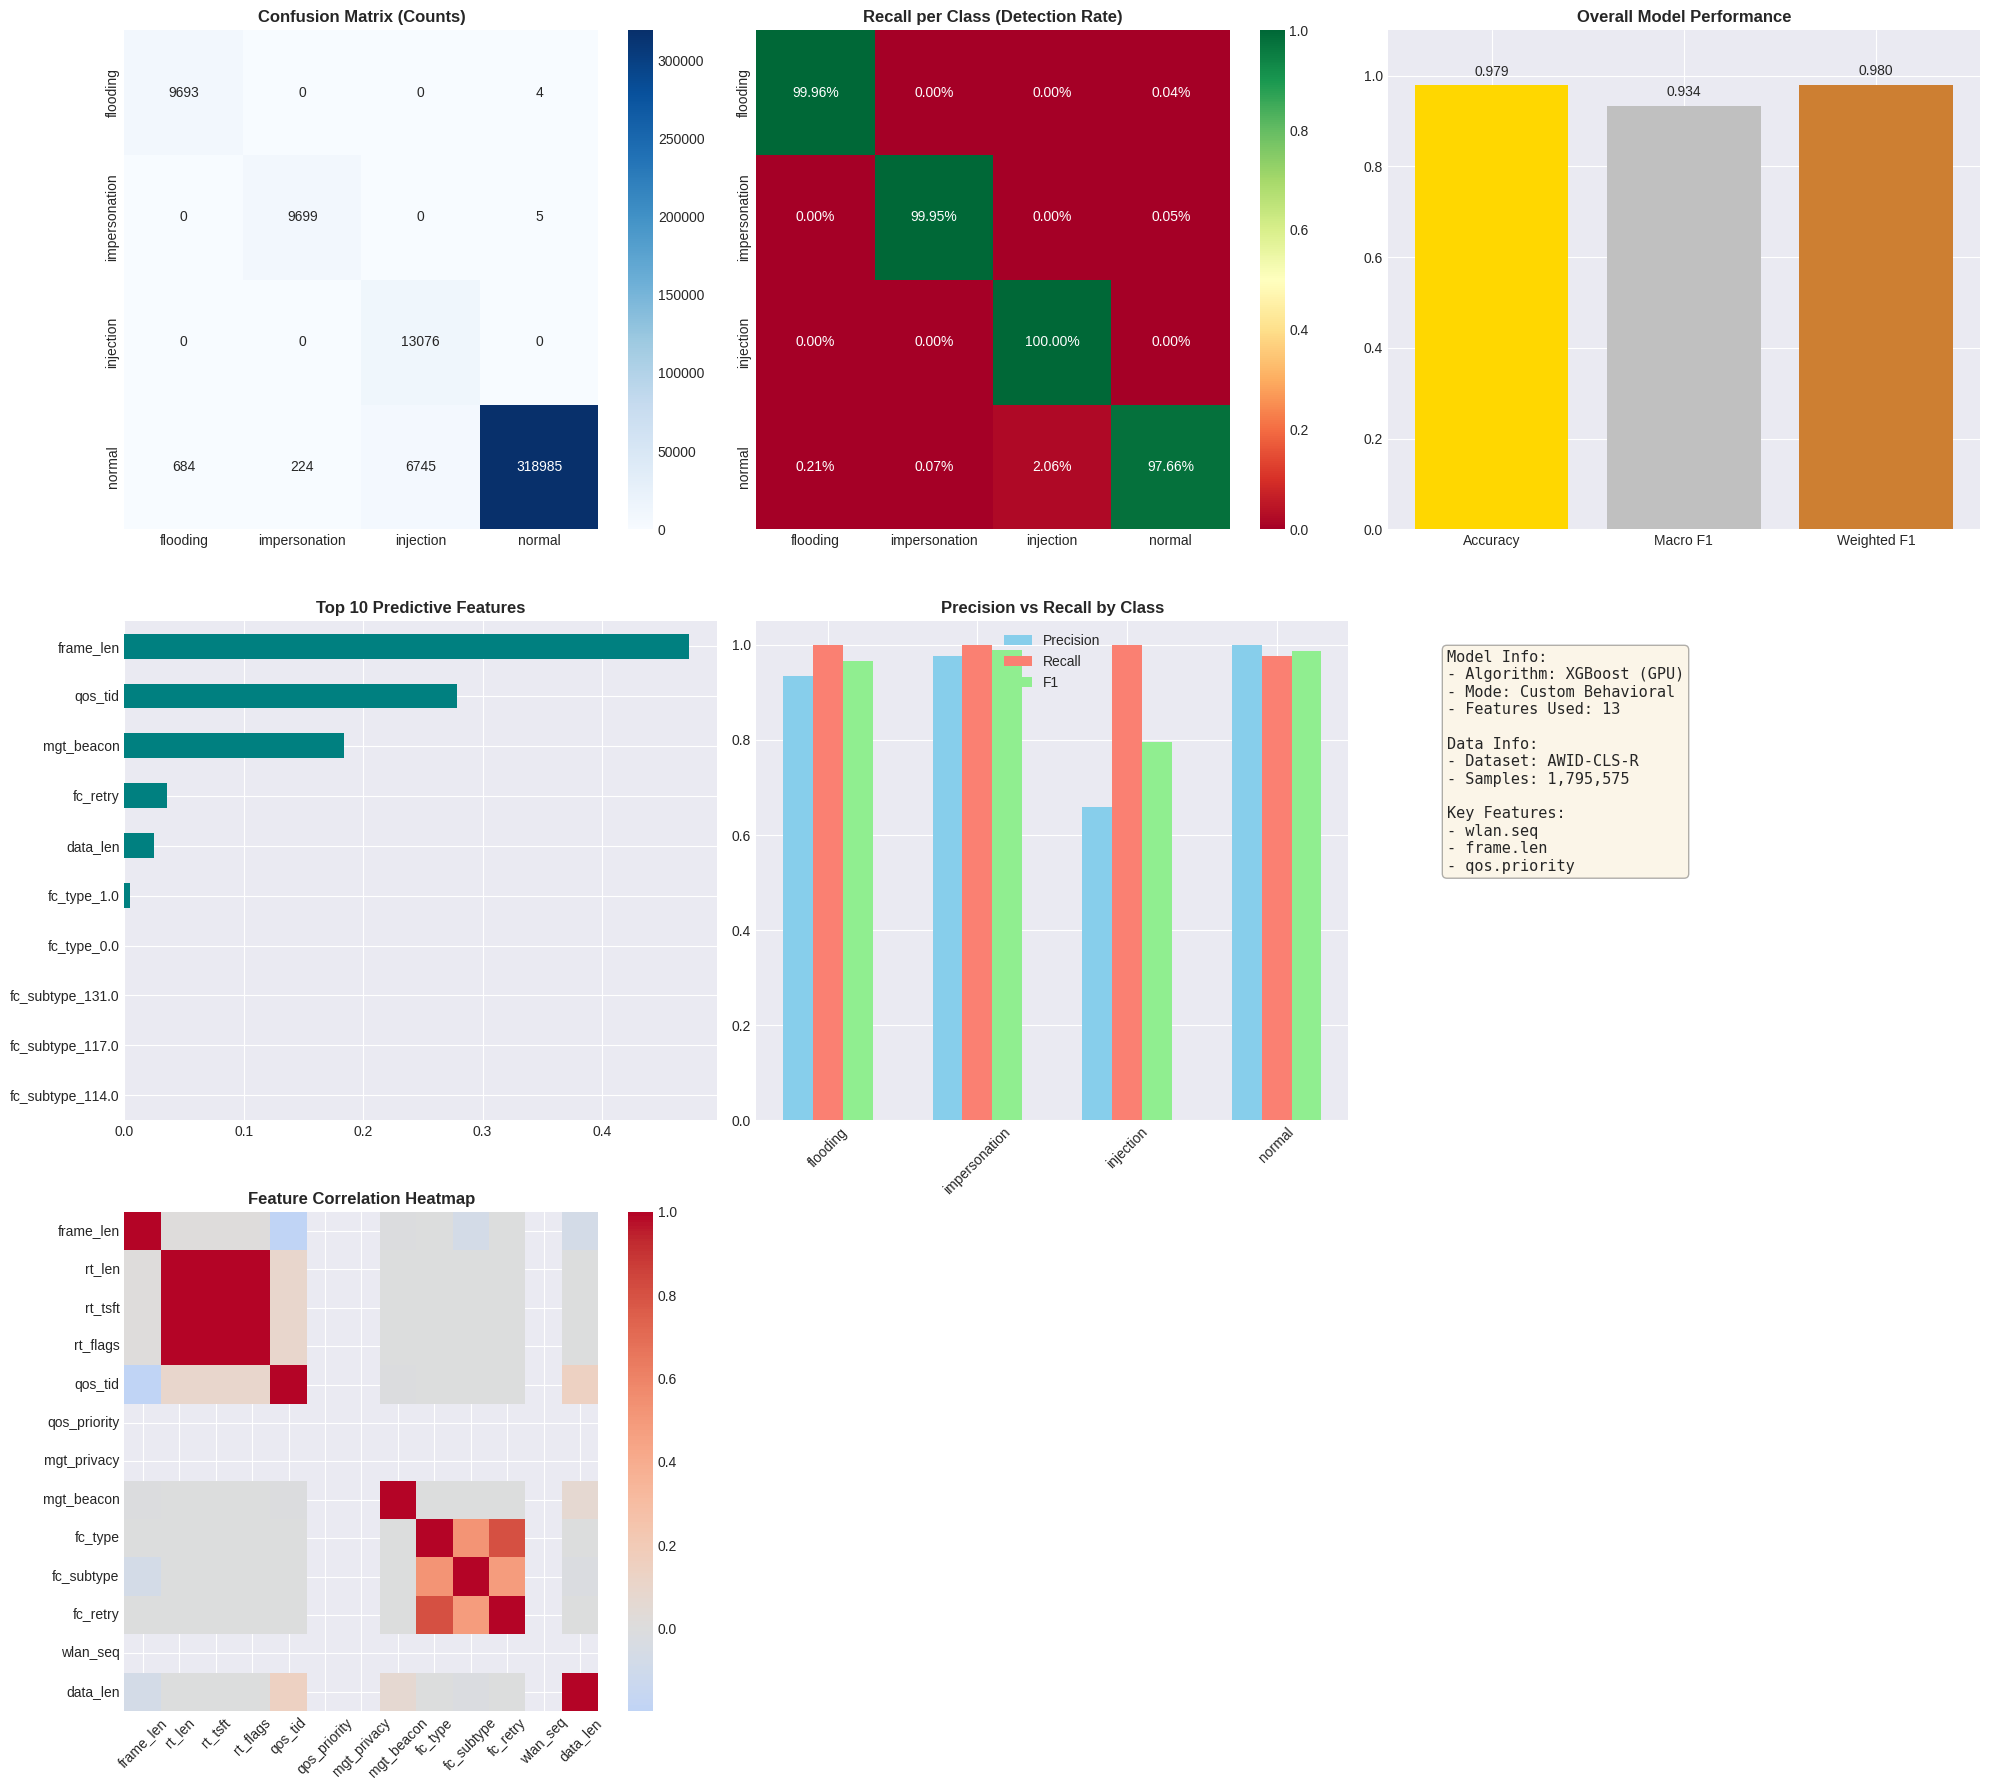


FINAL PERFORMANCE REPORT
               precision    recall  f1-score   support

     flooding       0.93      1.00      0.97      9697
impersonation       0.98      1.00      0.99      9704
    injection       0.66      1.00      0.79     13076
       normal       1.00      0.98      0.99    326638

     accuracy                           0.98    359115
    macro avg       0.89      0.99      0.93    359115
 weighted avg       0.99      0.98      0.98    359115



In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================================================
# STEP 0: GPU VERIFICATION
# ============================================================================
print("--- Step 0: Checking GPU Status ---")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ NO GPU DETECTED. Reverting to CPU.")

# ============================================================================
# STEP 1: LOAD YOUR SELECTED FEATURES
# ============================================================================
print("\n--- Step 1: Downloading & Loading Custom AWID Features ---")
path = kagglehub.dataset_download("zhiqingcui/awidclsr")
train_file = f'{path}/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

selected_feature_map = {
    7: 'frame_len',
    13: 'rt_len',
    14: 'rt_tsft',
    15: 'rt_flags',
    125: 'fc_type',
    126: 'fc_subtype',
    128: 'fc_retry',
    139: 'wlan_seq',
    140: 'data_len',
    63: 'mgt_privacy',
    68: 'mgt_beacon',
    37: 'qos_tid',
    38: 'qos_priority',
    154: 'class'
}

selected_cols = sorted(selected_feature_map.keys())
col_names = [selected_feature_map[k] for k in selected_cols]

print(f"--- Step 2: Loading Data with {len(col_names)-1} Behavioral Features ---")
df = pd.read_csv(train_file, header=None, usecols=selected_cols,
                 names=col_names, low_memory=False)

# ============================================================================
# STEP 3: PREPROCESSING
# ============================================================================
print("--- Step 3: Cleaning & Encoding ---")

for col in df.columns:
    if col != 'class':
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Store numeric df for the heatmap later
df_numeric_only = df.drop(columns=['class']).copy()

df_encoded = pd.get_dummies(df, columns=['fc_type', 'fc_subtype'])

le_target = LabelEncoder()
df_encoded['class'] = le_target.fit_transform(df_encoded['class'].astype(str))
class_names = le_target.classes_

X = df_encoded.drop('class', axis=1)
X = X.select_dtypes(include=[np.number, 'bool'])
y = df_encoded['class']

# ============================================================================
# STEP 4: BALANCING & TRAINING
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("--- Step 4: Applying SMOTE Balancing ---")
X_res, y_res = SMOTE(random_state=42, k_neighbors=1).fit_resample(X_train, y_train)

print(f"--- Step 5: Training GPU-XGBoost ---")
model = XGBClassifier(
    n_estimators=150,
    max_depth=10,
    tree_method='hist',
    device=device,
    random_state=42
)

start = time.time()
model.fit(X_res, y_res)
print(f"Training Time: {time.time() - start:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATION & VISUALIZATION
# ============================================================================
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Generating Visualizations ---")
fig = plt.figure(figsize=(20, 18)) # Increased height slightly for clarity

# 1. CONFUSION MATRIX
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')

# 2. RECALL HEATMAP
ax2 = plt.subplot(3, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Recall per Class (Detection Rate)', fontweight='bold')

# 3. PERFORMANCE METRICS
ax3 = plt.subplot(3, 3, 3)
metrics_summary = {
    'Accuracy': report['accuracy'],
    'Macro F1': report['macro avg']['f1-score'],
    'Weighted F1': report['weighted avg']['f1-score']
}
bars = ax3.bar(metrics_summary.keys(), metrics_summary.values(), color=['gold', 'silver', '#cd7f32'])
ax3.set_ylim(0, 1.1)
ax3.set_title('Overall Model Performance', fontweight='bold')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center')

# 4. FEATURE IMPORTANCE (TOP 10)
ax4 = plt.subplot(3, 3, 4)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(10)
feat_imp.plot(kind='barh', color='teal', ax=ax4)
ax4.set_title('Top 10 Predictive Features', fontweight='bold')

# 5. PRECISION/RECALL/F1
ax5 = plt.subplot(3, 3, 5)
x_axis = np.arange(len(class_names))
ax5.bar(x_axis - 0.2, [report[c]['precision'] for c in class_names], 0.2, label='Precision', color='skyblue')
ax5.bar(x_axis, [report[c]['recall'] for c in class_names], 0.2, label='Recall', color='salmon')
ax5.bar(x_axis + 0.2, [report[c]['f1-score'] for c in class_names], 0.2, label='F1', color='lightgreen')
ax5.set_xticks(x_axis)
ax5.set_xticklabels(class_names, rotation=45)
ax5.set_title('Precision vs Recall by Class', fontweight='bold')
ax5.legend()

# 6. MODEL INFO BOX
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
info_text = (f"Model Info:\n- Algorithm: XGBoost (GPU)\n- Mode: Custom Behavioral\n"
             f"- Features Used: {len(selected_cols)-1}\n\n"
             f"Data Info:\n- Dataset: AWID-CLS-R\n- Samples: {len(df):,}\n\n"
             f"Key Features:\n- wlan.seq\n- frame.len\n- qos.priority")
ax6.text(0.1, 0.5, info_text, fontsize=11, family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# --- NEW HEATMAP ADDITION ---
# 7. FEATURE CORRELATION HEATMAP
ax7 = plt.subplot(3, 3, 7)
corr_matrix = df_numeric_only.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax7, cbar=True)
ax7.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))